<a href="https://colab.research.google.com/github/AMujahid843/Final_report_STQD6324_Data_Management_-P166974-/blob/main/Final_report_STQD6324_Data_Management_(P166974).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FINAL REPORT STQD6324 DATA MANAGEMENT (P166974)**

##**INTRODUCTION**

<p align="justify">
&nbsp;&nbsp;&nbsp;&nbsp;Countries accross the globe experience different levels of development in which they are reflected through various socioeconomic, healthcare and environmental indicators. Factors such as population size, economic performance, healthcare investment and environmental conditions play vital roles in determining the overall well being and progress of a nation. This project aims to analyse population distribution and GDP per capita distribution across different countries, while also exploring trends in life expectancy to understand how these indicators vary globally. By examining these patterns, the project provides an overview of differences in development levels and highlights potential factors influencing national outcomes.
</p>
<p align="justify">
&nbsp;&nbsp;&nbsp;&nbsp;Furthermore, this project will focus on discovering relationships between two or more indicators to uncover possible connections between economic, health and environmental factors. The analysis examines relationships such as GDP per capita with CO2 emissions, health expenditure with life expectancy, mortality rate, HIV incidence and doctor density. These insights help explain how improvements in economic capacity and healthcare investment may influence population health and sustainability. Based on the findings, recommendations are proposed to support better healthcare planning, sustainable development and data driven decision making to further improve future global outcomes.
</p>



## **OBJECTIVES**

<p align="justify">
&nbsp;&nbsp;&nbsp;&nbsp;There are multiple factors used to measure the performance of countries across different dimensions, including economic, health and environmental aspects. Various indicators are commonly used as metrics to evaluate a country's overall development and output in these areas. These indicators help provide a comprehensive understanding of national performance by capturing key aspects such as economic growth, population health and environmental sustainability.
</p>
<p align="justify">
For the purpose of this project, 8 indicators from World Health Organization (WHO) and the World Bank are chosen to review the trend and uncover relationships between these indicators. The indicators include:

1.   Population
2.   GDP per capita;  measured in current US&#36;
3.   Current health expenditure per capita; measured in current US&#36;
4.   Life expectancy at birth; measured in years
5.   HIV infections; rate per 1000 uninfected population
6.   Density of doctors (physicians); rate per 10,000 population
7.   Under-five mortality rate; rate per 1000 live births
8.   Carbon dioxide (CO2) emissions; measured in Million Metric Tons of Carbon Dioxide Equivalent (Mt CO2e)

Based on these 8 indicators, there are few objectives that the project will aim to achieve. The objectives include:

*   To analyse population distribution by country  
*   To analyse GDP per capita distribution by country  
*   To discover trend in life expectancy
*   To discover relationships between two or more indicators
</p>

## **Definition of Each Indicator**

<p align="justify">

1.   **Population**: Total population is based on the de facto definition of population, which counts all residents regardless of legal status or citizenship. The values shown are midyear estimates.
2.   **Gross Domestic Product (GDP) per capita**: The sum of gross value added by all resident producers in the economy plus any product taxes (less subsidies) not included in the valuation of output, divided by mid-year population.
3.   **Current health expenditure per capita**: Current expenditures on health per capita in current US&#36; dollars. Estimates of current health expenditures include healthcare goods and services consumed during each year.
4.   **Life expectancy at birth**: Life expectancy at birth indicates the number of years a newborn infant would live if prevailing patterns of mortality at the time of its birth were to stay the same throughout its life.
5.   **HIV infections**: The number of new HIV infections per 1,000 uninfected population, by sex, age and key populations as defined as the number of new HIV infections per 1,000 persons among the uninfected population.
6.   **Density of doctors (physicians)**: The number of physicians includes generalists, specialist medical practitioners and medical doctors not further defined, in the given national and/or subnational area. Depending on the nature of the original data source, this may include practising (active) physicians only or all registered physicians. The ISCO-08 codes included here are 221, 2211 and 2212. The WHO framework for classifying health workers draws on the latest revisions of international classifications, including the International Standard Classification of Occupations (revision 2008), the International Standard Classification of Education (revision 2011) and the International Standard Industrial Classification of All Economic Activities (revision 4).
7.   **Under-five mortality rate**: The probability of a child born in a specific year or period dying before reaching the age of five, if subject to age-specific mortality rates of that period. Under-five mortality rate as defined here is strictly speaking not a rate (i.e. the number of deaths divided by the number of population at risk during a certain period of time) but a probability of death derived from a life table and expressed as rate per 1000 live births.
8.   **Carbon dioxide (CO2) emissions**: A measure of annual emissions of carbon dioxide (CO2), one of the six Kyoto greenhouse gases (GHG), from the agriculture, energy, waste, and industrial sectors, excluding LUCLUCF. The measure is standardized to carbon dioxide equivalent values using the Global Warming Potential (GWP) factors of IPCC's 5th Assessment Report (AR5).

</p>

####**Reference:**
(worldbank.org) from https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.DYN.LE00.IN

(www.who.int) from https://www.who.int/data/gho/indicator-metadata-registry

##**Data Sources**

<p align="justify">
This analysis uses data from the World Bank Open Data Indicators and World Health Organization Data Indicators.
Raw Dataset were downloaded into csv files from these websites:

World Bank: https://data.worldbank.org/

World Health Organization: https://data.who.int/indicators
</p>

## **Data Cleaning**

<p align="justify">
The downloaded raw datasets will be uploaded and cleaned. The data cleaning process includes removing missing values, reset the index as well as keeping the necessary columns (country, year and value). In addition, some of the raw datasets consist regions or class in the "country" column such as "Africa Eastern and Southern", "East Asia & Pacific (excluding high income)" to name a few. Therefore, "pycountry" library will be installed and applied to include official countries only in the "country" column. The cleaned dataset will be saved for further analysis. The data cleaning process for all 8 indicators are performed separately and will be saved for further analysis.
</p>

In [1]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 78.0 MB/s eta 0:00:00


In [2]:
# Population
import pandas as pd
from google.colab import files
import pycountry

uploaded = files.upload()

# Load dataset
pop = pd.read_csv("Total Population.csv", skiprows=4)

# Identify year columns
year_columns = [col for col in pop.columns if str(col).isdigit()]

# Convert wide format to long format
pop_long = pd.melt(
    pop,
    id_vars=["Country Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

# Remove missing values
pop_long = pop_long.dropna(subset=["Value"])

# Convert year to integer
pop_long["Year"] = pop_long["Year"].astype(int)

# Rename columns to 'country', 'year', 'value'
pop_long.rename(columns={'Country Name': 'country', 'Year': 'year', 'Value': 'value'}, inplace=True)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
pop_long_clean = pop_long[pop_long["country"].isin(countries)].copy()

# Reset index
pop_long_clean = pop_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
pop_long_clean.to_csv("Total_Population_Cleaned.csv", index=False, header=False)

print(pop_long_clean.head())

Saving Total Population.csv to Total Population.csv
       country  year      value
0        Aruba  1960    54922.0
1  Afghanistan  1960  9035043.0
2       Angola  1960  5231654.0
3      Albania  1960  1608800.0
4      Andorra  1960     9510.0


In [3]:
# GDP per capita
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
gdppc = pd.read_csv("GDP Per Capita.csv", skiprows=4)

# Identify year columns
year_columns = [col for col in gdppc.columns if str(col).isdigit()]

# Convert wide format to long format
gdppc_long = pd.melt(
    gdppc,
    id_vars=["Country Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

# Remove missing values
gdppc_long = gdppc_long.dropna(subset=["Value"])

# Convert year to integer
gdppc_long["Year"] = gdppc_long["Year"].astype(int)

# Rename columns to 'country', 'year', 'value'
gdppc_long.rename(columns={'Country Name': 'country', 'Year': 'year', 'Value': 'value'}, inplace=True)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
gdppc_long_clean = gdppc_long[gdppc_long["country"].isin(countries)].copy()

# Reset index
gdppc_long_clean = gdppc_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
gdppc_long_clean.to_csv("GDP_Per_Capita_Cleaned.csv", index=False, header=False)

print(gdppc_long_clean.head())

Saving GDP Per Capita.csv to GDP Per Capita.csv
     country  year        value
0  Argentina  1960   778.251707
1  Australia  1960  1813.431099
2    Austria  1960   939.914815
3    Burundi  1960    70.905100
4    Belgium  1960  1290.286072


In [4]:
# Current health expenditure per capita
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
health = pd.read_csv("Health Expenditure Per Capita.csv", skiprows=4)

# Identify year columns
year_columns = [col for col in health.columns if str(col).isdigit()]

# Convert wide format to long format
health_long = pd.melt(
    health,
    id_vars=["Country Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

# Remove missing values
health_long = health_long.dropna(subset=["Value"])

# Convert year to integer
health_long["Year"] = health_long["Year"].astype(int)

# Rename columns to 'country', 'year', 'value'
health_long.rename(columns={'Country Name': 'country', 'Year': 'year', 'Value': 'value'}, inplace=True)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
health_long_clean = health_long[health_long["country"].isin(countries)].copy()

# Reset index
health_long_clean = health_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
health_long_clean.to_csv("Health_Expenditure_per_Capita_Cleaned.csv", index=False, header=False)

print(health_long_clean.head())

Saving Health Expenditure Per Capita.csv to Health Expenditure Per Capita.csv
                country  year        value
0                Angola  2000    13.159986
1               Albania  2000    65.476746
2               Andorra  2000  1294.091187
3  United Arab Emirates  2000   706.031128
4             Argentina  2000   702.233093


In [5]:
# Life expectancy
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
le = pd.read_csv("Life Expectancy.csv")

# Select the relevant columns and rename them as specified
le_long =le[['GEO_NAME_SHORT', 'DIM_TIME', 'AMOUNT_N']].copy()
le_long.rename(columns={'GEO_NAME_SHORT': 'country', 'DIM_TIME': 'year', 'AMOUNT_N': 'value'}, inplace=True)

# Remove missing values in the 'value' column
le_long =le_long.dropna(subset=['value'])

# Convert year to integer
le_long['year'] = le_long['year'].astype(int)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
le_long_clean = le_long[le_long["country"].isin(countries)].copy()

# Reset index
le_long_clean = le_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
le_long_clean.to_csv("Life_Expectancy_Cleaned.csv", index=False, header=False)

print(le_long_clean.head())

Saving Life Expectancy.csv to Life Expectancy.csv
        country  year      value
0        Serbia  2000  74.334559
1    Seychelles  2000  76.455919
2  Sierra Leone  2000  51.577824
3     Singapore  2000  80.774170
4      Slovakia  2000  77.405510


In [6]:
# Under-five mortality rate
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
under5 = pd.read_csv("Under 5 Mortality Rate.csv")

# Select the relevant columns and rename them as specified
under5_long =under5[['GEO_NAME_SHORT', 'DIM_TIME', 'RATE_PER_1000_N']].copy()
under5_long.rename(columns={'GEO_NAME_SHORT': 'country', 'DIM_TIME': 'year', 'RATE_PER_1000_N': 'value'}, inplace=True)

# Remove missing values in the 'value' column
under5_long =under5_long.dropna(subset=['value'])

# Convert year to integer
under5_long['year'] = under5_long['year'].astype(int)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
under5_long_clean = under5_long[under5_long["country"].isin(countries)].copy()

# Reset index
under5_long_clean = under5_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
under5_long_clean.to_csv("Under_5_Mortality_Rate_Cleaned.csv", index=False, header=False)

print(under5_long_clean.head())

Saving Under 5 Mortality Rate.csv to Under 5 Mortality Rate.csv
    country  year       value
0     Spain  1950  103.373676
1  Eswatini  1950  231.559869
2  Eswatini  1950  252.145096
3  Eswatini  1950  242.217885
4    Sweden  1950   23.569498


In [7]:
# HIV infections
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
hiv = pd.read_csv("HIV Infections.csv")

# Select the relevant columns and rename them as specified
hiv_long = hiv[['GEO_NAME_SHORT', 'DIM_TIME', 'RATE_PER_1000_N']].copy()
hiv_long.rename(columns={'GEO_NAME_SHORT': 'country', 'DIM_TIME': 'year', 'RATE_PER_1000_N': 'value'}, inplace=True)

# Remove missing values in the 'value' column
hiv_long = hiv_long.dropna(subset=['value'])

# Convert year to integer
hiv_long['year'] = hiv_long['year'].astype(int)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
hiv_long_clean = hiv_long[hiv_long["country"].isin(countries)].copy()

# Reset index
hiv_long_clean = hiv_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
hiv_long_clean.to_csv("HIV_Infections_Cleaned.csv", index=False, header=False)

print(hiv_long_clean.head())

Saving HIV Infections.csv to HIV Infections.csv
      country  year  value
0   Australia  1992   0.10
1     Bahamas  1992   1.80
2     Bahrain  1992   0.10
3  Bangladesh  1992   0.01
4     Armenia  1992   0.01


In [8]:
# Density of doctors
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
dd = pd.read_csv("Density of Doctors.csv")

# Select the relevant columns and rename them as specified
dd_long =dd[['GEO_NAME_SHORT', 'DIM_TIME', 'RATE_PER_10000_N']].copy()
dd_long.rename(columns={'GEO_NAME_SHORT': 'country', 'DIM_TIME': 'year', 'RATE_PER_10000_N': 'value'}, inplace=True)

# Remove missing values in the 'value' column
dd_long =dd_long.dropna(subset=['value'])

# Convert year to integer
dd_long['year'] = dd_long['year'].astype(int)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
dd_long_clean = dd_long[dd_long["country"].isin(countries)].copy()

# Reset index
dd_long_clean = dd_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
dd_long_clean.to_csv("Density_of_Doctors_Cleaned.csv", index=False, header=False)

print(dd_long_clean.head())

Saving Density of Doctors.csv to Density of Doctors.csv
      country  year  value
0     Albania  1990  13.78
1  Azerbaijan  1990  38.02
2   Australia  1990  21.60
3     Austria  1990  30.08
4     Belgium  1990  32.67


In [9]:
# Carbon dioxide (CO2) emissions
from google.colab import files
import pandas as pd
import pycountry

uploaded = files.upload()

# Load dataset
CO2 = pd.read_csv("CO2 Emissions.csv", skiprows=4)

# Identify year columns
year_columns = [col for col in CO2.columns if str(col).isdigit()]

# Convert wide format to long format
CO2_long = pd.melt(
    CO2,
    id_vars=["Country Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

# Remove missing values
CO2_long = CO2_long.dropna(subset=["Value"])

# Convert year to integer
CO2_long["Year"] = CO2_long["Year"].astype(int)

# Rename columns to 'country', 'year', 'value'
CO2_long.rename(columns={'Country Name': 'country', 'Year': 'year', 'Value': 'value'}, inplace=True)

# Keep only official countries
countries = [country.name for country in pycountry.countries]
CO2_long_clean = CO2_long[CO2_long["country"].isin(countries)].copy()

# Reset index
CO2_long_clean = CO2_long_clean.reset_index(drop=True)

# Save cleaned dataset without header
CO2_long_clean.to_csv("CO2_Emissions_Cleaned.csv", index=False, header=False)

print(CO2_long_clean.head())

Saving CO2 Emissions.csv to CO2 Emissions.csv
                country  year    value
0                 Aruba  1970   0.0254
1           Afghanistan  1970   1.7328
2                Angola  1970   8.9339
3               Albania  1970   4.8451
4  United Arab Emirates  1970  19.4648


## **INSIGHTS AND EXPLANATIONS**


## **Population**


<p align="justify">
Total population is extracted to get a general overview of the total population by countries and identify top and bottom 10 countries for the population. The cleaned csv file for population, "Total_Population_Cleaned.csv" is imported in HIVE in the form of a table and is queried through HIVE QL (HQL) to extract the top 10 countries for total population from the latest year of the available data. The query is shown below:
</p>


```sql
SELECT t.country AS country,
       t.total_population AS population,
       t.year AS year
FROM total_population_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM total_population_cleaned
) y
ON t.year = y.latest_year
ORDER BY population DESC
LIMIT 10;
```

<p align="justify">
The output from the HQL query is shown in the table below:
</p>

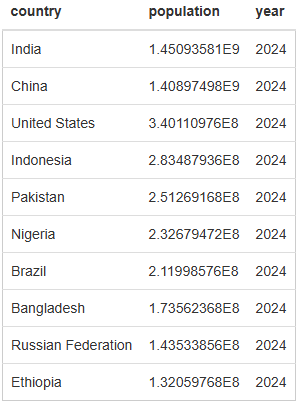

<p align="justify">
From the table output above, the top 10 countries by population are well displayed with India ranked top and the tenth rank nation is Ethiopia. However, the value for the "population" column is quite hard to interpret due to the numbers are very large. It is also known that this data took the latest available year, 2024 for the output. In order to properly identify a clear picture of the top 10 countries by population, the table above is converted into a csv file called "top 10 population (2024).csv" and a bar graph is visualised and is shown as per below:
</p>

Saving top 10 population (2024).csv to top 10 population (2024).csv


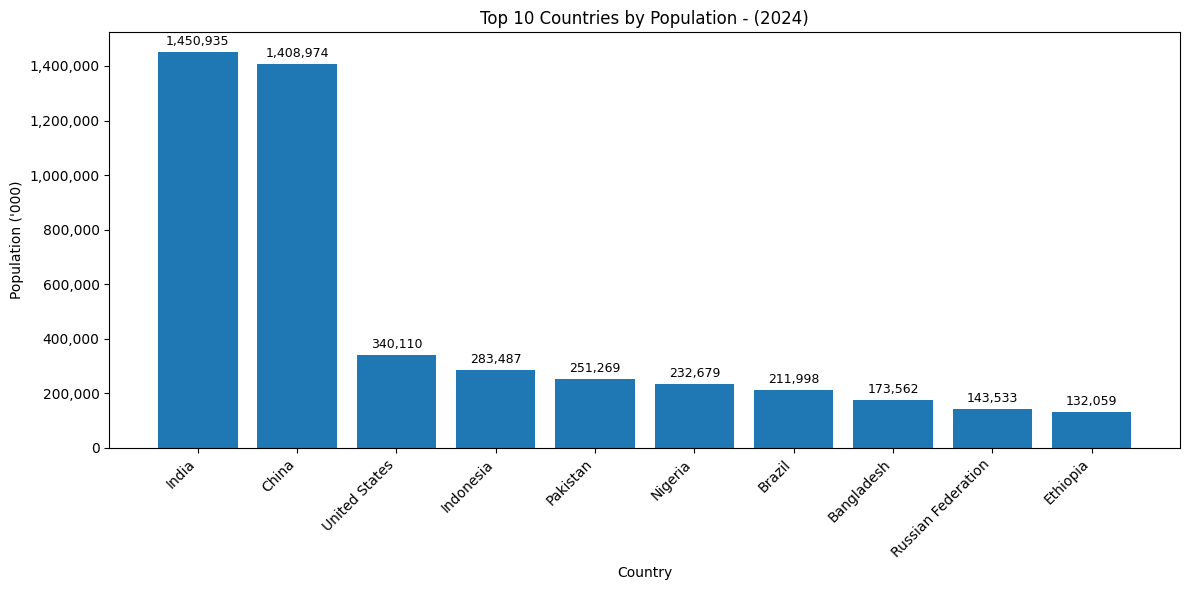

In [10]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

uploaded = files.upload()

# ---------------------------------
# Load CSV
# ---------------------------------
df_pop = pd.read_csv("top 10 population (2024).csv")

# ---------------------------------
# Convert data types
# ---------------------------------
df_pop["country"] = df_pop["country"].astype(str)
df_pop["year"] = df_pop["year"].astype(int)
df_pop["population"] = pd.to_numeric(df_pop["population"], errors="coerce")

# ---------------------------------
# Top 10 countries
# ---------------------------------
top10 = df_pop.sort_values(
    by="population",
    ascending=False
)

# ---------------------------------
# Visualization
# ---------------------------------
plt.figure(figsize=(12, 6))
bars_top = plt.bar(top10["country"], top10["population"])

plt.title("Top 10 Countries by Population - (2024)")
plt.xlabel("Country")
plt.ylabel("Population ('000)")  # <-- updated ylabel

# ---------------------------------
# Y-axis in thousand format
# ---------------------------------
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x/1000):,}")
)

plt.xticks(rotation=45, ha='right')

# ---------------------------------
# Add value labels (in '000 format)
# ---------------------------------
for bar in bars_top:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + top10["population"].max() * 0.01,
        f"{int(height/1000):,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<p align="justify">
In 2024, India and China dominates the total population massively among all other countries with 1,450,935,000 and 1,408,975,000 total population respectively with the third country with highest population (United States) and the rest are very far behind. United States has population of 340,110,000 with Indonesia (283,487,000) and Pakistan (251,269,000) are the fourth and fifth largest countries in the world by population respectively. Nigeria has around 230 million population (232,679,000) and it is followed by the other four countries to fill in the rest of the top 10 countries in the world by population, ordered by Brazil (211,998,000), Bangladesh (173,562,000), Russian Federation (143,533,000) and Ethiopia which ranked tenth nation in the entire world for population where its total population is 132,059,000.
</p>

<p align="justify">
From the list of countries above, a common similarity is that they generally have very large land areas. Hence, it allows them to accomodate the large number of populations in their countries. However, it is worth to take note that even though the countries have large land area, it is not necessarily mean that all the area are habitable or populated. Some part of these countries may consist of deserts, mountains, forests or other uninhabitable environments. Another important factor to consider is the ratio between the total population to land area which is known as population density. Although India is the largest country in the world by population, it does not have the largest land area and is ranked seventh in the world (britannica.com). In contrast, Russia has the largest land area in the world. In this instace, India is a more densely populated country compared to Russia because a significantly larger number of people live within a smaller land area, whereas Russia has a much lower population distributed across a much larger territory.
</p>

<p align="justify">
High density country like India might impact the quality of life of the people there. Some of the negative impact of denser nation is overcrowding in cities that may lead to several serious challenges that can significantly reduce quality of life (bbc.com). The demand for housing often exceeds supply due to increase in population density. This will result in housing shortages, rising property prices and the expansion of informal settlements where living conditions are poor. Healthcare systems will be put on heavy pressure due to dense population which can cause longer waiting times and reduce the overall quality and accessibility of medical services. On top of that, high population concentration contributes to severe traffic congestion and increased pollution, which will further affects public health and daily productivity. Clean water, sanitation, transportation and other public infrastructure as essential resources and services also become strained under the growing population load, making them less efficient and harder to access. Finally, competition for limited jobs and educational opportunities will increase as well that can lead to higher unemployment rates, inequality and social stress among urban populations.
</p>

####**Reference:**
(britannica.com) from https://www.britannica.com/topic/list-of-the-total-areas-of-the-worlds-countries-dependencies-and-territories-2130540

(bbc.com) from https://www.bbc.com/news/world-asia-india-65309567

<p align="justify">
Bottom 10 countries are queried through HQL from the "Total_Population_Cleaned.csv" file. The HQL query is shown below:
</p>

```sql
SELECT t.country AS country,
       t.total_population AS population,
       t.year AS year
FROM total_population_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM total_population_cleaned
) y
ON t.year = y.latest_year
ORDER BY population ASC
LIMIT 10;
```

<p align="justify">
The table below displays the bottom 10 countries by population in the world in 2024:
</p>

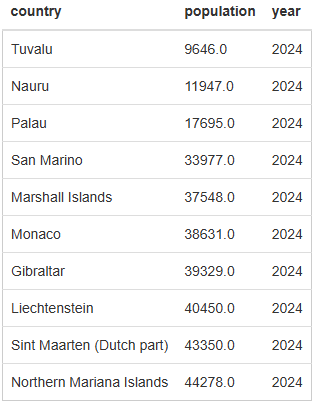

<p align="justify">
As compared to largest countries by nation, the population value is quite interpretaple as it ranged between thousands to ten of thousands only. However, a bar graph is created to properly display the distribution of these countries. The table above is converted into a csv file named "bottom 10 population (2024).csv"
</p>

Saving bottom 10 population (2024).csv to bottom 10 population (2024).csv


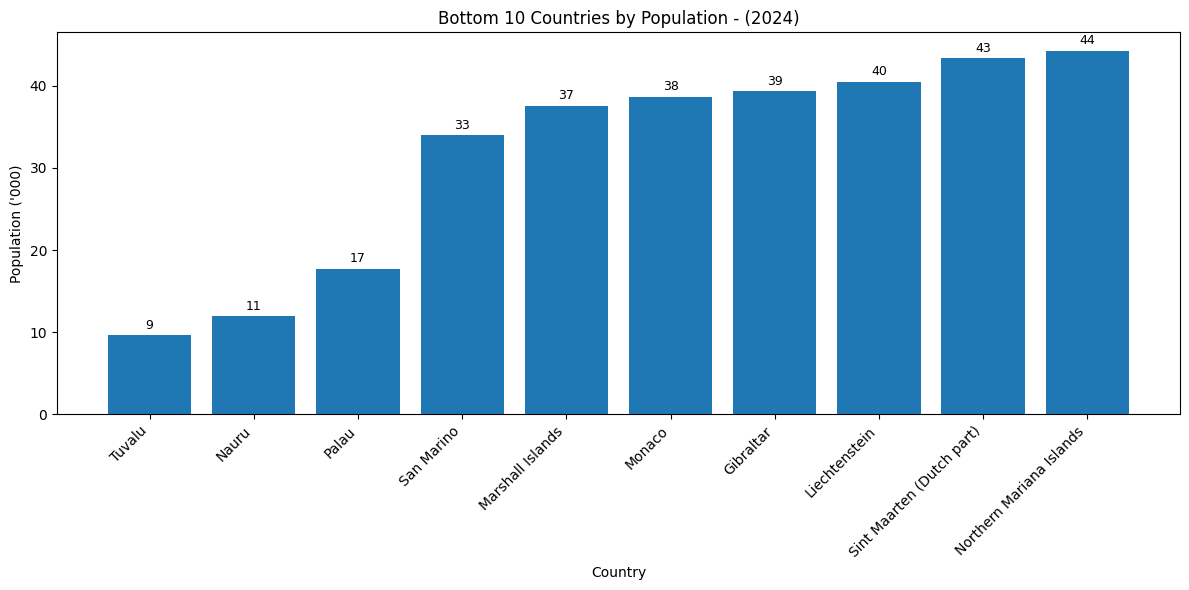

In [11]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

uploaded = files.upload()

# ---------------------------------
# Load CSV
# ---------------------------------
df_pop = pd.read_csv("bottom 10 population (2024).csv")

# ---------------------------------
# Convert data types
# ---------------------------------
df_pop["country"] = df_pop["country"].astype(str)
df_pop["year"] = df_pop["year"].astype(int)
df_pop["population"] = pd.to_numeric(df_pop["population"], errors="coerce")

# ---------------------------------
# Bottom 10 countries
# ---------------------------------
bottom10 = df_pop.sort_values(
    by="population",
    ascending=True
)

# ---------------------------------
# Visualization
# ---------------------------------
plt.figure(figsize=(12, 6))
bars_bottom = plt.bar(bottom10["country"], bottom10["population"])

plt.title("Bottom 10 Countries by Population - (2024)")
plt.xlabel("Country")
plt.ylabel("Population ('000)")

# ---------------------------------
# Y-axis in thousand format
# ---------------------------------
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x/1000):,}")
)

plt.xticks(rotation=45, ha='right')

# ---------------------------------
# Add value labels (in '000 format)
# ---------------------------------
for bar in bars_bottom:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + bottom10["population"].max() * 0.01,
        f"{int(height/1000):,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<p align="justify">
The massive gap between the largest nations and the smallest nations can clearly be seen from the number of populations in the countries. Using the available data from the most recent year (2024), Tuvalu is considered as the smallest country by population with only around 9,000 people in the country. This is hundred thousand time lesser than India. This shows significant diference between the largest and smallest nations. Nauru and Palau followed closely with 11,000 and 17,000 respectively. There is quite significant jump between the third smallest country and the fourth with San Marino has almost the double amount of the Palau's population (33,000). Marshall Islands, Monaco and Gibraltar are countries that are within the 40,000 total population mark where they have 37,000, 38,000 and 39,000 total population respectively. Liechtenstein (40,000), Sint Maarten (43,000) and Northen Mariana Islands (44,000) rank eighth to tenth for the smallest nations in the world.
</p>

<p align="justify">
In contrast to the biggest nations in the world, these nations have small number of total population is due to the size of their land areas. They do not have the capabilities to accomodate the large number of populations in their countries. Although the countries are small in terms of population, they are few advantages of countries with lesser people. Small nations are generally easier to govern because decision-making processes are simpler and more centralized. Policies can be implemented more efficiently by the government and respond faster to national issues due to fewer administrative layers and a smaller geographic area. Shorter distances and higher population concentration make it easier for the citizens to access essential services such as healthcare, education and transportation. Public facilities are typically more evenly distributed, allowing governments to provide services more effectively and ensure broader coverage of the population. Many small nations succeed by specializing in specific economic sectors such as finance, tourism or technology. This specialization allows them to integrate effectively into the global economy, attract foreign investment and maintain high income levels despite having limited natural resources or land area.
</p>


## **GDP per Capita**

<p align="justify">
Total GDP only is not the best indicator to compare economic output among all countries due to it lacks consideration of the population of the countries. Higher populous countries might have higher GDP due to more resources available to them in terms of the number of workforces available. This will impact the countries' economic output. Smaller nations do not have the luxury of this and might be the reason for lower GDP output. Hence, why GDP per capita is applied for this analysis as it takes into account the population of the countries as well. It measures the total GDP over the total population which will give the average economic output. The top 10 countries with highest GDP per capita based on the latest available year are extracted to get an insight on the countries' characteristics. The data is queried through HQL from the cleaned "GDP_Per_Capita_Cleaned.csv" file. The HQL query is shown below:
</p>

```sql
SELECT t.country AS country,
       t.gdp_per_capita AS gdp_per_capita,
       t.year AS year
FROM gdp_per_capita_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM gdp_per_capita_cleaned
) y
ON t.year = y.latest_year
ORDER BY gdp_per_capita DESC
LIMIT 10;
```

<p align="justify">
The HQL query above displays below table:
</p>

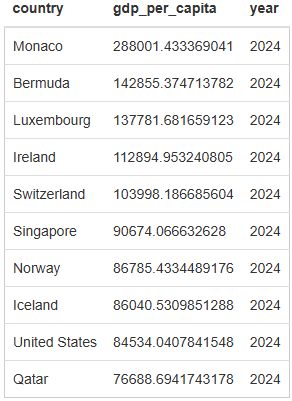

<p align="justify">
Although the list of countries with highest GDP per capita can be clearly seen from the table above, a proper bar graph representation will be more insightful to identify the characteristics of these nations and observe any significant differences in terms of the GDP per capita amount between the countries. The table above is converted into a csv file named "top 10 gdp per capita (2024).csv" and the bar plot is displayed by running python code. The bar graph is shown below: </p>

Saving top 10 gdp per capita (2024).csv to top 10 gdp per capita (2024).csv


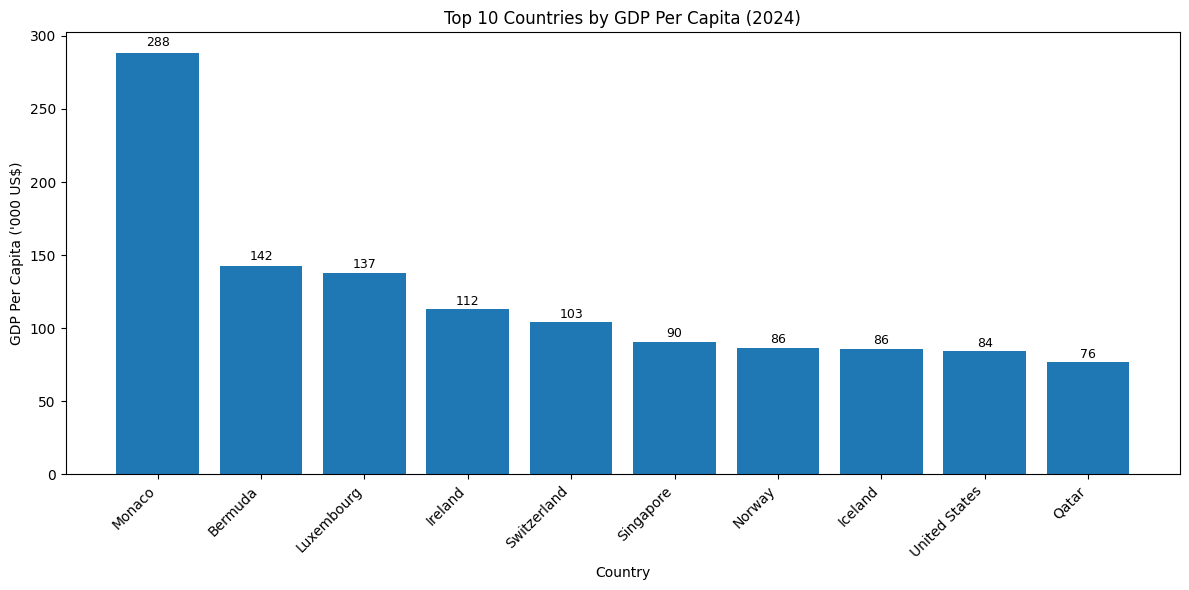

In [12]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

uploaded = files.upload()

# ---------------------------------
# Load CSV
# ---------------------------------
df_gdp = pd.read_csv("top 10 gdp per capita (2024).csv")

# ---------------------------------
# Convert data types
# ---------------------------------
df_gdp["country"] = df_gdp["country"].astype(str)
df_gdp["year"] = df_gdp["year"].astype(int)
df_gdp["gdp_per_capita"] = pd.to_numeric(df_gdp["gdp_per_capita"], errors="coerce")

# ---------------------------------
# Top 10 countries by GDP per capita
# ---------------------------------
top10 = df_gdp.sort_values(
    by="gdp_per_capita",
    ascending=False
)

# ---------------------------------
# Visualization
# ---------------------------------
plt.figure(figsize=(12, 6))
bars_top = plt.bar(top10["country"], top10["gdp_per_capita"])

plt.title("Top 10 Countries by GDP Per Capita (2024)")
plt.xlabel("Country")
plt.ylabel("GDP Per Capita ('000 US$)")

# ---------------------------------
# Y-axis in thousand format
# ---------------------------------
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x/1000):,}")
)

plt.xticks(rotation=45, ha='right')

# ---------------------------------
# Add value labels (in '000 format)
# ---------------------------------
for bar in bars_top:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{int(height/1000):,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<p align="justify">
Monaco tops the list for GDP per capita in 2024 with a massive difference compare to other countries in the world with a whopping 288,000 US&#36; which is double the amount of Bermuda which sit on second place (142,000 US&#36;). Luxembourg (137,000 US&#36;), Ireland (112,000 US&#36;) and Switzerland (103,000 US&#36;) are all above the 100,000 US&#36; mark for GDP per capita. Singapore sit at sixth with 90,000 US&#36. Norway and Iceland ranked seventh with 86,000 US&#36; followed by United States (84,000 US&#36;) and Qatar (76,000 US&#36;) as the tenth country with highest GDP per capita in 2024.
</p>

<p align="justify">
The GDP per capita bar plot above suggests that country with high total GDP does not guarantee it has a high GDP per capita as it is now taken into account the population of the country as well to find about the average economic output per person in the country. There are a lot of small nations in this bar graph. It indicates that these small nations are able to generate quite significant of GDP output and match the other nations as well. In fact, Monaco, one of the smallest country by population managed to top for GDP per capita. Monaco has the highest GDP per capita in the world mainly due to a combination of extreme population size, economic structure and tax policies. The microstate is able to generate billions in economic output. The fact that it also attracts a very large number of high-net-worth individuals and wealthy residents due to its zero personal income tax, strong financial privacy and political stability. This leads to high levels of spending, investment, luxury consumption and real estate activity, all of which contribute strongly to GDP (tradecouncil.org).
</p>

<p align="justify">
Although the top countries with the highest GDP per capita are predominantly small nations such as Luxembourg, Monaco and Singapore, the United States stands out as a remarkable exception. In contrast to the small nations that benefit from GDP per capita due to their high GDP and low population, the United States has a population of more than 300 million people and is among the largest countries in the world in terms of both population and land area. Despite this, it consistently ranks among the countries with the highest GDP per capita, demonstrating the immense strength and productivity of its economy. The United States has been able to achieve this through its diversified economy, technological innovation, highly developed financial markets, strong industrial base and global influence in sectors such as technology, healthcare, finance and manufacturing. Furthermore, the country is home to many of the world's largest multinational corporations, which contribute substantially to economic output and wealth creation (researchfdi.com).
</p>

####**Reference:**
(tradecouncil.org) from https://tradecouncil.org/wp-content/uploads/2025/01/Investing-in-Monaco.pdf

(researchfdi.com) from https://researchfdi.com/why-the-us-leads-the-world-in-entrepreneurship-and-innovation/

<p align="justify">
Same methodology applies for bottom 10 countries by GDP per capita. The "GDP_Per_Capita_Cleaned.csv" file is converted into a table in HIVE and the bottom 10 countries is queried from HQL. The HQL query and the list of countries are shown below:
</p>

```sql
SELECT t.country AS country,
       t.gdp_per_capita AS gdp_per_capita,
       t.year AS year
FROM gdp_per_capita_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM gdp_per_capita_cleaned
) y
ON t.year = y.latest_year
ORDER BY gdp_per_capita ASC
LIMIT 10;
```

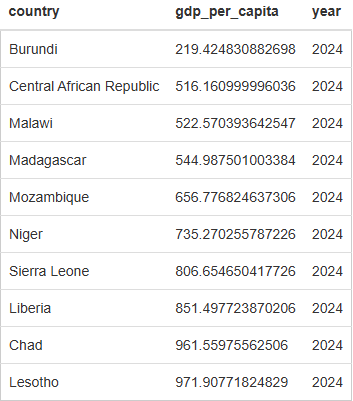

<p align="justify">
The table above is not a best representation to compare the GDP per capita between countries and hence bar plot is created to observe the GDP per capita differences between bottom 10 countries. The table above is converted into a csv file "bottom 10 gdp per capita (2024).csv" and then displayed as bar plot based on the python code below:
</p>

Saving bottom 10 gdp per capita (2024).csv to bottom 10 gdp per capita (2024).csv


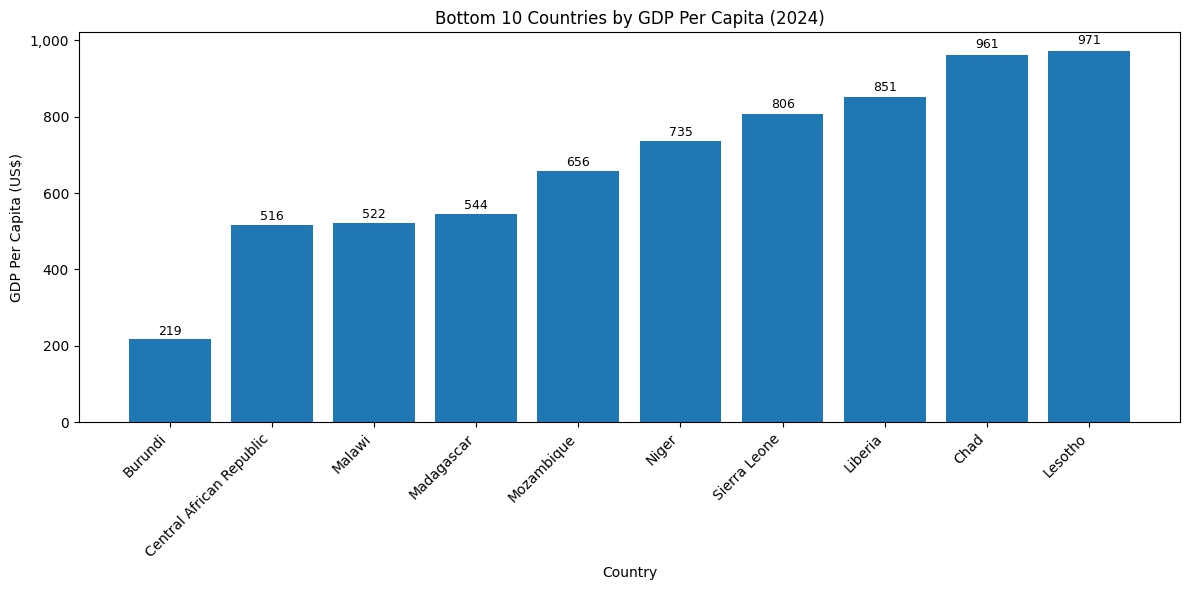

In [13]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

uploaded = files.upload()

# ---------------------------------
# Load CSV
# ---------------------------------
df_gdp = pd.read_csv("bottom 10 gdp per capita (2024).csv")

# ---------------------------------
# Convert data types
# ---------------------------------
df_gdp["country"] = df_gdp["country"].astype(str)
df_gdp["year"] = df_gdp["year"].astype(int)
df_gdp["gdp_per_capita"] = pd.to_numeric(df_gdp["gdp_per_capita"], errors="coerce")

# ---------------------------------
# Bottom 10 countries by GDP per capita
# ---------------------------------
bottom10 = df_gdp.sort_values(
    by="gdp_per_capita",
    ascending=True
)

# ---------------------------------
# Visualization
# ---------------------------------
plt.figure(figsize=(12, 6))
bars_bottom = plt.bar(bottom10["country"], bottom10["gdp_per_capita"])

plt.title("Bottom 10 Countries by GDP Per Capita (2024)")
plt.xlabel("Country")
plt.ylabel("GDP Per Capita (US$)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars_bottom:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<p align="justify">
In contrast to the nations with highest GDP per capita, the nations in above bar plot are well behind in terms of GDP per capita compared to nations in previous bar graph. Bottom 10 countries for GDP per capita do not even achieve 1,000 US&#36 mark with Burundi has the lowest GDP per capita (219 US&#36;). There is quite significant jump in the GDP per capita value for the second lowest nation in Central African Republic (516 US&#36;). This is followed by Malawi (522 US&#36;), Madagascar (544 US&#36;), Mozambique (656 US&#36;) which ranked third to fifth from bottom. Niger has GDP per capita of 735 US&#36, Sierra Leone has 806 US&#36 and Liberi has 851 US&#36. Chad and Lesotho filled in the remaining bottom 10 for GDP per capita with 961 US&#36; and 971 US&#36; respectively.
</p>

<p align="justify">
From the list of countries above, one common similarity is that they are all located in Africa. Many African countries are still developing and generally have lower levels of economic growth compared to countries in Europe, North America and parts of Asia. Factors such as limited infrastructure, lower industrial development, political instability and high poverty rates have slowed progress in some countries. As a result, governments often have fewer resources to invest in healthcare, education and other essential public services. This can affect the quality of healthcare available to the population, leading to lower life expectancy and higher mortality rates. Therefore, the presence of many African countries among the lowest-performing nations in certain health and economic indicators suggests that economic development plays an important role in improving population well-being and overall quality of life.
</p>

## **Life Expectancy**




<p align="justify">
One of the widely used health indicator is Life Expectancy. It is commonly use to get an overview of the overall health performance in particular countries. The average life expectancy by country is displayed in below table. To get an overview on the average value that will be calculated later, the range of the oldest and latest available year is extracted and is shown below as per below HQL query:
</p>

```sql
SELECT MIN(year) AS oldest_year,
       MAX(year) AS latest_year
FROM life_expectancy_cleaned;
```

<p align="justify">
The query above extracted the information from the "Life_Expectancy_Cleaned.csv" file in the form of a table in HIVE. The output from the query is shown below:
</p>

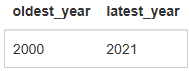

<p align="justify">
From the output above, the available data for life expectancy were only from year 2000 until 2021 and the average life expectancy value for each country will be based on these years and the HQL query and the output are shown below:
</p>

```sql
SELECT country,
       AVG(life_expectancy) AS avg_life_expectancy
FROM life_expectancy_cleaned
GROUP BY country
LIMIT 10;
```

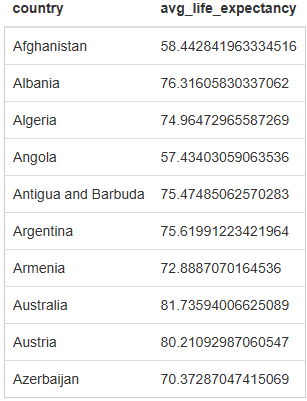

<p align="justify">
Table above displays the first 10 countries average life expectancy value in alphabetical order. From the table above, Afghanistan and Angole have quite low average life expectancy with both of the countries have less than 60 years old for life span. There is limited evaluation can be made from the table alone since it only shows value for several countries it is hard to do analysis from the table. Instead of calculating the average life expectancy by country, a better analysis for this indicator is by plotting life expectancy trend. Therefore, average life expectancy is calculated by year and this is then plotted from the year 2000 until 2021 to get an overview of the global life expectancy trend over the past years. The global life expectancy by year is tabulated using the HQL query below:
</p>

```sql
SELECT year,
       AVG(life_expectancy) AS global_avg_life_expectancy
FROM life_expectancy_cleaned
GROUP BY year
ORDER BY year ASC;
```

<p align="justify">
Calculating the average life expectancy by year and order it from the oldest year to the latest year will give below result:
</p>

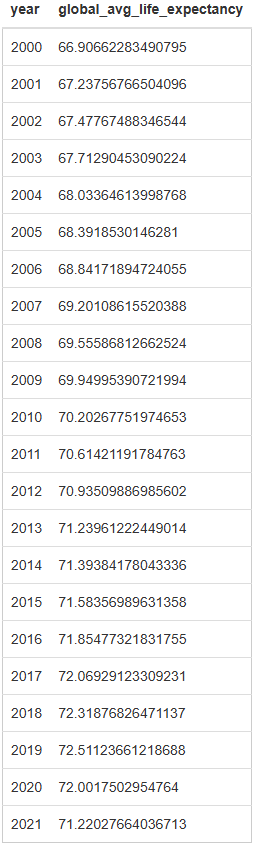

<p align="justify">
Based on the table above, there were changes on the global life expectancy year by year. However, the trend is quite hard to be intrpreted based on the table alone. A graphical trendline would be more useful for the representation the the global average life expectancy accross years. This table is converted into a csv file called "global life expectancy trend.csv" and the trend is displayed in a time series plot using the below python code:
</p>

Saving global life expectancy trend.csv to global life expectancy trend.csv


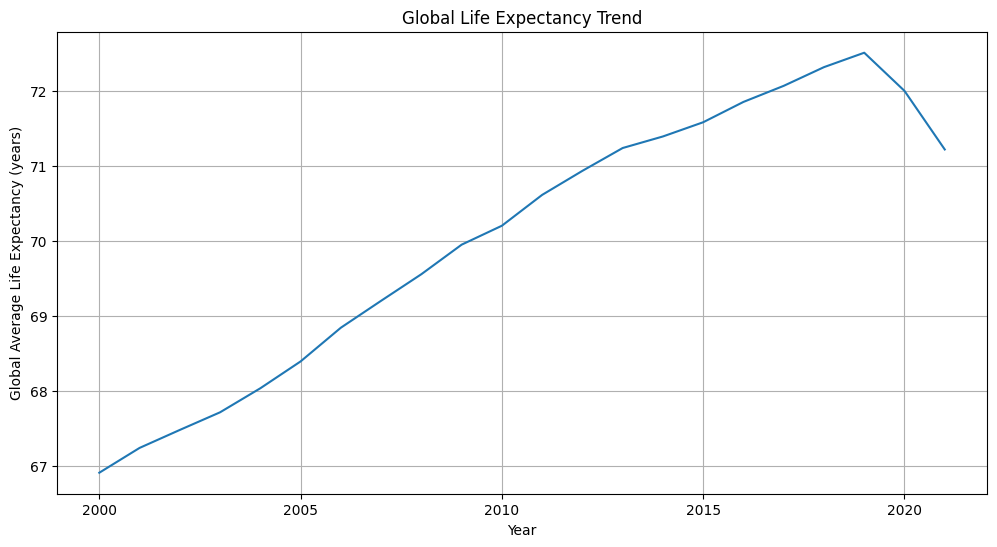

In [14]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("global life expectancy trend.csv")

# ----------------------------
# 2. Convert data types
# ----------------------------
df["year"] = df["year"].astype(int)
df["global_avg_life_expectancy"] = pd.to_numeric(
    df["global_avg_life_expectancy"],
    errors="coerce"
)

# ----------------------------
# 3. Sort values
# ----------------------------
df = df.sort_values("year")

# ----------------------------
# 4. Drop missing values
# ----------------------------
df = df.dropna(subset=["global_avg_life_expectancy"])

# ----------------------------
# 5. Plot time series (global trend)
# ----------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["global_avg_life_expectancy"]
)

plt.xlabel("Year")
plt.ylabel("Global Average Life Expectancy (years)")
plt.title("Global Life Expectancy Trend")
plt.grid(True)

plt.show()

<p align="justify">
The graph above illustrates the trend of average global life expectancy from the year 2000 until 2021. Overall, there is a clear upward trend in global life expectancy, increasing from approximately 67 years in 2000 to a peak of more than 72 years just before 2020. This indicates a significant improvement in global health conditions over nearly two decades, with life expectancy increasing by more than four years during this period. Such growth reflects substantial progress in healthcare services, disease prevention, medical technology and overall living standards across many countries. However, after reaching its highest point, life expectancy experienced a noticeable decline of about one year, falling to around 71 years. This sudden decrease is concerning because it interrupted a long-term pattern of continuous improvement and suggests that major global events can have a significant impact on population health outcomes.
</p>
<p align="justify">
The steady increase in life expectancy over the years can be attributed to several factors. Improvements in healthcare systems, wider access to medical services, advancements in medical technology and better disease prevention programs have helped reduce mortality rates and extend human lifespan. In addition, greater public awareness regarding healthy lifestyles, improved nutrition, better sanitation and increased access to clean water have contributed to healthier populations worldwide. Economic development has also played an important role, as countries with higher income levels are generally able to invest more in healthcare infrastructure, healthcare professionals and public health initiatives. These combined factors have led to better management of both communicable and non-communicable diseases, allowing people to live longer and healthier lives.
</p>
<p align="justify">
On the other hand, the sharp decline in life expectancy observed around 2020 can largely be associated with the COVID-19 pandemic, which affected countries across the globe. The pandemic caused millions of deaths and placed enormous pressure on healthcare systems, disrupting medical services and reducing access to healthcare for many individuals. According to the World Health Organization, the COVID-19 pandemic reversed several years of progress in global life expectancy due to its widespread health and social impacts (www.who.int). In addition to the direct loss of life caused by the virus, the pandemic also contributed to economic disruptions, mental health challenges, delayed medical treatments and increased strain on healthcare resources. These factors collectively contributed to the decline in average life expectancy during this period. Furthermore, based on the available data, there appears to be no strong sign of a full recovery to pre-pandemic life expectancy levels, indicating that the long-term effects of the pandemic may continue to influence global health outcomes for several years. This highlights the importance of strengthening healthcare systems, improving public health preparedness and developing effective strategies to manage future global health crises.
</p>


####**Reference:**
(www.who.int) from https://www.who.int/news/item/24-05-2024-covid-19-eliminated-a-decade-of-progress-in-global-level-of-life-expectancy

## **GDP per Capita and Health Expenditure per Capita Relationship**

<p align="justify">
Since GDP per capita is considered one of the main indicators of a country's economic performance, its relationship with other indicators is important in uncovering meaningful insights about a nation's development and well-being. A higher GDP per capita generally indicates that a country has greater economic resources, which may allow governments and individuals to spend more on healthcare services and medical facilities. Therefore, analyzing the relationship between GDP per capita and health expenditure per capita can help determine whether countries with stronger economies tend to invest more in healthcare. Understanding this relationship is important because healthcare spending is often associated with improvements in healthcare quality, accessibility and overall population health outcomes. Hence, the relationship between GDP per capita and health expenditure per capita is analysed to observe whether there is a correlation between these two indicators. Below HQL query displays the average GDP per capita and average health expenditure per capita by country based on the cleaned datasets, "GDP_Per_Capita_Cleaned.csv" and "Health_Expenditure_per_Capita_Cleaned.csv"
</p>

```sql
SELECT g.country AS country,
       AVG(g.gdp_per_capita) AS avg_gdp,
       AVG(h.health_expenditure_per_capita) AS avg_health_expenditure
FROM gdp_per_capita_cleaned g
JOIN health_expenditure_per_capita_cleaned h
ON g.country = h.country
AND g.year = h.year
GROUP BY g.country;
```

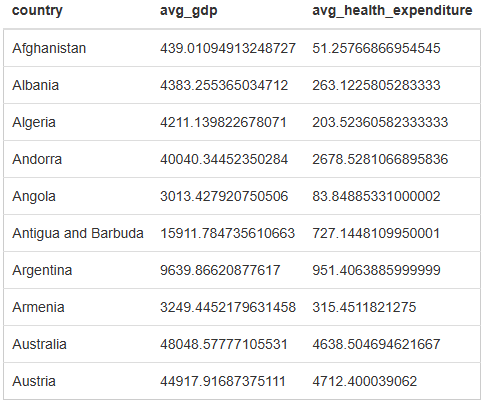

<p align="justify">
Table above only displays the first 10 rows from the overall table. Based on the table above, only average GDP per capita and average health expenditure per capita by country are captured. There is no proper representation of the relationship from this table alone. In order to uncover the relationship between these two indicators, a scatter plot of health expenditure per capita and GDP per capita is plot to visualise and capture any relationship that may exist between the indicators. The output from above HQL query is converted into a csv file "gdp vs health.csv" and the scatter plot of average health expenditure per capita and average GDP per capita is displayed below:
</p>

Saving gdp vs health.csv to gdp vs health.csv
Correlation between Average GDP per Capita and Health Expenditure per Capita: 0.90


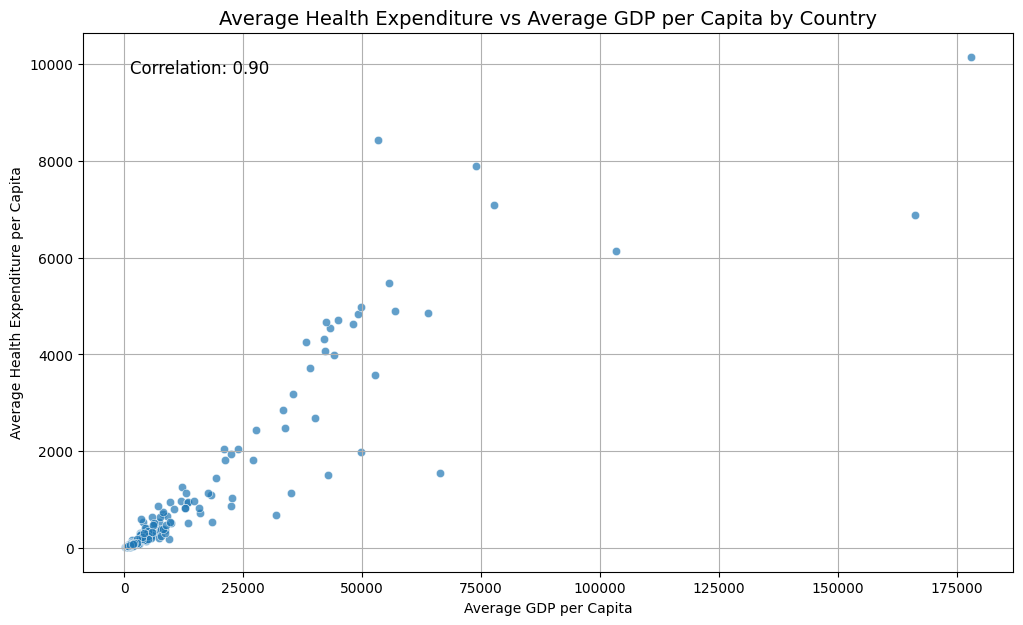

In [15]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("gdp vs health.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_gdp"] = pd.to_numeric(result["avg_gdp"], errors="coerce")
result["avg_health_expenditure"] = pd.to_numeric(result["avg_health_expenditure"], errors="coerce")

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(subset=["avg_gdp", "avg_health_expenditure"])

# ---------------------------------
# Correlation
# ---------------------------------
correlation = result["avg_gdp"].corr(result["avg_health_expenditure"])
print(f"Correlation between Average GDP per Capita and Health Expenditure per Capita: {correlation:.2f}")

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="avg_gdp",
    y="avg_health_expenditure",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title("Average Health Expenditure vs Average GDP per Capita by Country", fontsize=14)
plt.xlabel("Average GDP per Capita")
plt.ylabel("Average Health Expenditure per Capita")
plt.grid(True)

plt.show()

<p align="justify">
From the scatter plot above, it shows that there is positive relationship between GDP per capita and the health expenditure per capita. As GDP per capita increases, the health expenditure per capita increases as well. The top left of the plot shows the strength of the relationship shown by the correlation value. In this case, the correlation value is 0.90, really close to value 1 and this correspond to a very strong relationship. Countries with higher GDP per capita tend to spend more on healthcare for each individual. The reason for this is because wealthier countries usually have stronger economies, higher government revenues and greater financial resources that enable them allocate the resources toward healthcare services, medical technologies, healthcare infrastructure and healthcare professionals. As income levels increase, both governments and individuals are often able to spend more on healthcare. This eventually will lead to higher health expenditure per capita. Richer countries generally devote a larger share of their income to healthcare compared to lower income countries.
</p>
<p align="justify">
However, the relationship is not perfectly linear as can be seen in the plot whereby the plot is quite spread out towards the higher GDP per capita. Some countries spend significantly more on healthcare than others despite having almost similar GDP per capita levels. This indicates that factors such as government healthcare policies, healthcare system efficiency, population age structure and public health priorities also influence healthcare spending. Therefore, while higher GDP per capita often leads to greater healthcare expenditure, economic wealth alone does not fully determine the effectiveness or quality of a country's healthcare system.
</p>
<p align="justify">
It is now known that the indicators have positive relationship. However, the significance of the predictor (average GDP per capita) cannot be extracted solely based on the plot itself. Hence, the p-value for the predictor is calculated using Ordinary Least Squared (OLS) regression. For this case, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is average GDP per capita.
</p>

In [16]:
import statsmodels.api as sm

# Define the independent variable (X) as the average GDP per capita
X = result['avg_gdp']
# Define the dependent variable (y) as the average health expenditure per capita
y = result['avg_health_expenditure']

# Add a constant to the independent variable for the intercept of the regression line
X_with_const = sm.add_constant(X)

# Fit the ordinary least squares (OLS) regression model
model = sm.OLS(y, X_with_const).fit()

# Print the summary of the regression model, which includes coefficients, R-squared, p-values, etc.
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     avg_health_expenditure   R-squared:                       0.811
Model:                                OLS   Adj. R-squared:                  0.810
Method:                     Least Squares   F-statistic:                     717.6
Date:                    Sun, 07 Jun 2026   Prob (F-statistic):           2.39e-62
Time:                            01:56:38   Log-Likelihood:                -1368.8
No. Observations:                     169   AIC:                             2742.
Df Residuals:                         167   BIC:                             2748.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

<p align="justify">
The OLS regression results from the table above provide several insights into the relationship between GDP per capita and health expenditure per capita. R-squared value is 0.811. This means that 81.1% of the variation in Health expenditure per capita can be explained by GDP per capita. 'avg_gdp' (GDP per capita) has very low p-value (0.000), which is less than the conventional significance level of 0.05. This means that the null hypothesis is rejected. Therefore, it is proven that GDP per capita is statistically significant predictor towards health expenditure per capita based on the result above. In summary, the regression analysis further prove that there is a statistically significant positive relationship between a country's GDP per capita and its health expenditure per capita. As GDP per capita increases, health GDP per capita tends to increase.
</p>
<p align="justify">
Since the relationship between GDP per capita and health expenditure per capita has been analysed, further analysis will be performed to uncover any other relationship between other indicators. Health expenditure per capita is a health indicator that may have relationships with other health indicators as well, namely, life expectancy, under-5 mortality rate, HIV incidence and density of doctors.
</p>

## **Health Expenditure per Capita and Life Expectancy Relationship**

<p align="justify">
To start off, relationship between health expenditure per capita and life expectancy is investigated. Does higher expenditure per capita led to longer life expectancy? This can be visualised by plotting the life expectancy against health expenditure per capita. Prior to the plotting process, the average health expenditure per capita and life expectancy will be calculated for each country to obtain a more representative overview of the relationship between healthcare spending and population health outcomes. This can be achieved by querying the HQL below to get the average values for each country:
</p>

```sql
SELECT h.country AS country,
       AVG(h.health_expenditure_per_capita) AS avg_health_expenditure,
       AVG(l.life_expectancy) AS avg_life_expectancy
FROM health_expenditure_per_capita_cleaned h
JOIN life_expectancy_cleaned l
ON h.country = l.country
AND h.year = l.year
GROUP BY h.country;
```

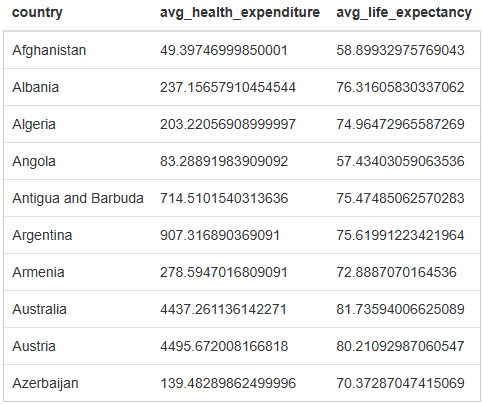

<p align="justify">
The table above only displays the first 10 rows of the table. The table is converted into a csv file "health vs life.csv" and the scatter plot of the average life expectancy is plot against the average health expenditure per capita. This is shown below:
</p>

Saving health vs life.csv to health vs life.csv
Correlation between Log(Health Expenditure per Capita) and Life Expectancy: 0.81


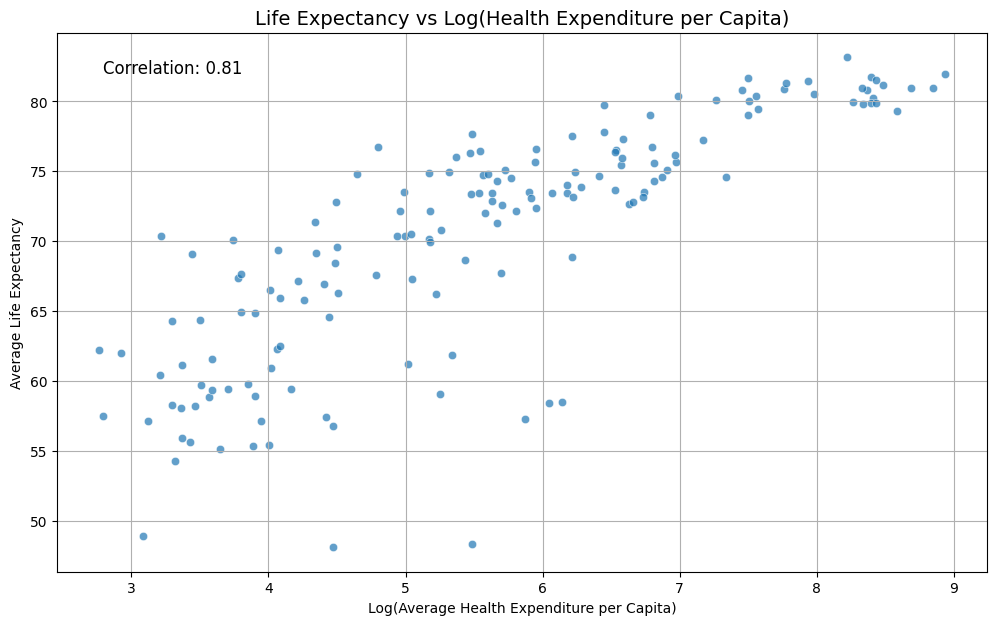

In [17]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("health vs life.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_health_expenditure"] = pd.to_numeric(result["avg_health_expenditure"], errors="coerce")
result["avg_life_expectancy"] = pd.to_numeric(result["avg_life_expectancy"], errors="coerce")

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(subset=["avg_health_expenditure", "avg_life_expectancy"])

# ---------------------------------
# Log transformation (health expenditure)
# ---------------------------------
result["log_avg_health_expenditure"] = np.log(result["avg_health_expenditure"])

# Remove invalid log values
result = result.replace([np.inf, -np.inf], np.nan).dropna()

# ---------------------------------
# Correlation (log scale)
# ---------------------------------
correlation = result["log_avg_health_expenditure"].corr(result["avg_life_expectancy"])
print(f"Correlation between Log(Health Expenditure per Capita) and Life Expectancy: {correlation:.2f}")

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="log_avg_health_expenditure",
    y="avg_life_expectancy",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title("Life Expectancy vs Log(Health Expenditure per Capita)", fontsize=14)
plt.xlabel("Log(Average Health Expenditure per Capita)")
plt.ylabel("Average Life Expectancy")
plt.grid(True)

plt.show()

<p align="justify">
For the plot above, the average health expenditure per capita is log scaled since it ranges from a few hundred to tens of thousands compared to life expectancy which generally has small spread. Using log scale spreads points out nicely. The correlation value from the top left of the plot shows the strength of the relationship. In this case, the correlation is 0.81 which correspond to very strong positive relationship. As health expenditure per capita increases, the life expectancy tend to increase. Countries that spend more on healthcare for each individual generally achieve longer life expectancy. This may be attributed to better access to healthcare services, improved medical technologies, higher quality treatment, greater availability of healthcare professionals and more effective disease prevention and health promotion programmes (Sarah, Isabel and Abhishek, 2022). Increased healthcare spending can contribute to lower mortality rates and improved population health outcomes which ultimately leading to longer average lifespans.
</p>
<p align="justify">
However, healthcare expenditure is not the only factor that affects life expectancy. Other factors such as income levels, education, environmental quality and the effectiveness of healthcare systems also play important roles. For example, higher income and education levels can improve access to nutritious food, better living conditions and health knowledge, while clean environment help reduce the spread of diseases. Therefore, although higher healthcare spending is strongly associated with longer life expectancy, differences in life expectancy across countries are influenced by a combination of healthcare, social economic and environmental factors.
</p>
<p align="justify">
From this relationship analysis, there is clear strong positive relationship based on the plot. In order to statistically proof that there is enough evidence to conclude that health expenditure per capita affect life expectancy positively, the p-value for the predictor (health expenditure per capita) is calculated using OLS regression. For this relationship, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is average health expenditure per capita.
</p>

####**Reference:**
 Sarah Galvani-Townsend, Isabel Martinez and Abhishek Pandey (2022). Is life expectancy higher in countries and territories with publicly funded health care? Global analysis of health care access and the social determinants of health

In [18]:
import statsmodels.api as sm

# Define the independent variable (X) as the log average of health expenditure per capita
X_health_life = result['log_avg_health_expenditure']
# Define the dependent variable (y) as the average life expectancy
y_health_life = result['avg_life_expectancy']

# Add a constant for the intercept
X_health_life_with_const = sm.add_constant(X_health_life)

# Fit the OLS regression model
model_health_life = sm.OLS(y_health_life, X_health_life_with_const, missing='drop').fit()

# Print the summary
print(model_health_life.summary())

                             OLS Regression Results                            
Dep. Variable:     avg_life_expectancy   R-squared:                       0.656
Model:                             OLS   Adj. R-squared:                  0.654
Method:                  Least Squares   F-statistic:                     297.5
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):           5.54e-38
Time:                         02:02:03   Log-Likelihood:                -474.40
No. Observations:                  158   AIC:                             952.8
Df Residuals:                      156   BIC:                             958.9
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

<p align="justify">
The OLS regression results shown in the table above provide further evidence of the relationship between health expenditure per capita and life expectancy. The model produces an R-squared value of 0.656, indicating that approximately 65.6% of the variation in life expectancy across countries can be explained by differences in health expenditure per capita. This suggests that healthcare spending is an important factor influencing population health outcomes. Countries that invest more resources in healthcare generally tend to achieve higher life expectancy. However, the remaining 34.4% of the variation is not explained by the model, indicating that other factors also contribute to differences in life expectancy.
</p>
<p align="justify">
The regression coefficient for 'log_avg_health_expenditure' is statistically significant, with a p-value of 0.000, which is well below the conventional significance level of 0.05. Therefore, the null hypothesis is rejected and there is sufficient evidence to conclude that health expenditure per capita has a significant relationship with life expectancy. Nevertheless, this result should be interpreted with caution, as healthcare expenditure is not the only determinant of longevity. Other socioeconomic and environmental factors, such as income levels, education and healthcare system efficiency, may also influence life expectancy as mentioned previously. As a result, while increased healthcare spending is associated with longer life expectancy, it should be considered alongside these other important factors when evaluating population health outcomes.
</p>


## **Health Expenditure per Capita and Under-five Mortality Rate Relationship**

<p align="justify">
Under-five mortality rate is an important indicator of a country's healthcare quality and overall level of development. Since the relationship between health expenditure per capita and life expectancy has been analysed, it is also important to uncover relationship between health expenditure per capita and under-five mortality rate. Based on the cleaned datasets; "Health_Expenditure_per_Capita_Cleaned.csv" and "Under_5_Mortality_Rate_Cleaned.csv", a query to extract average health expenditure per capita and the average under-five mortality rate is executed in HQL as per below:
</p>

```sql
SELECT h.country AS country,
       AVG(h.health_expenditure_per_capita) AS avg_health_expenditure,
       AVG(u.under_5_mortality_rate) AS avg_under_5_mortality_rate
FROM health_expenditure_per_capita_cleaned h
JOIN under_5_mortality_rate_cleaned u
ON h.country = u.country
AND h.year = u.year
GROUP BY h.country;
```

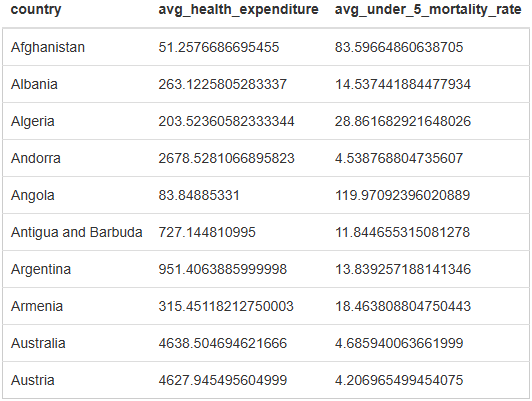

<p align="justify">
Table above displays the first 10 rows from the query's output. Converting the table into csv file called "health vs mortality.csv" and a scatter plot of average mortality rate is plot against the log average health expenditure per capita using below python code. Log scaled is used for health expenditure since it has very big spread compared to mortality rate. The plot is shown below:
</p>

Saving health vs mortality.csv to health vs mortality.csv
Correlation between Log(Health Expenditure per Capita) and Under-5 Mortality Rate: -0.77


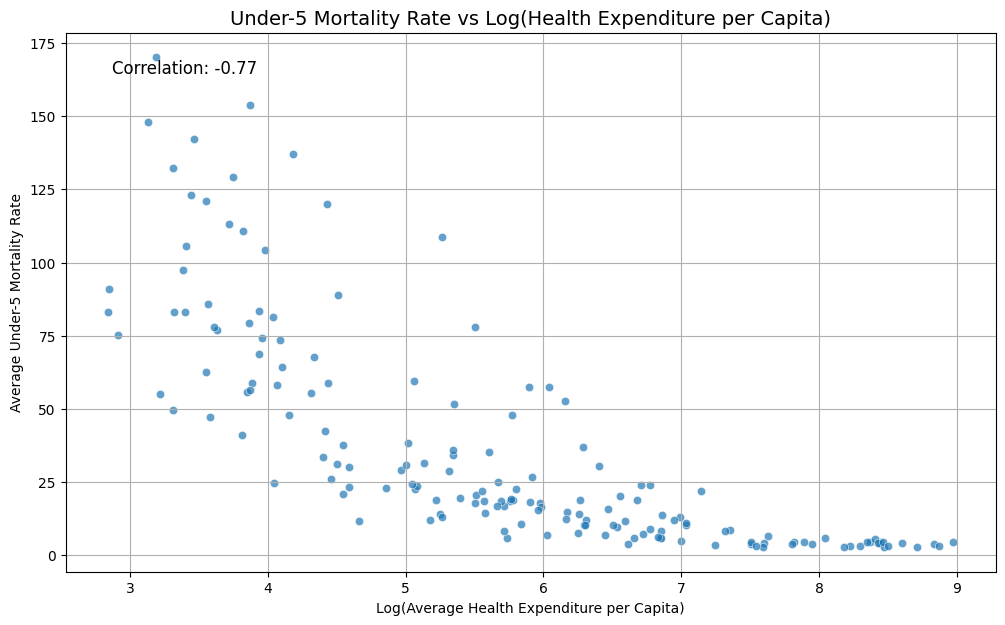

In [19]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("health vs mortality.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_health_expenditure"] = pd.to_numeric(
    result["avg_health_expenditure"],
    errors="coerce"
)

result["avg_under_5_mortality_rate"] = pd.to_numeric(
    result["avg_under_5_mortality_rate"],
    errors="coerce"
)

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(
    subset=["avg_health_expenditure", "avg_under_5_mortality_rate"]
)

# ---------------------------------
# Log transformation (health expenditure)
# ---------------------------------
result["log_avg_health_expenditure"] = np.log(
    result["avg_health_expenditure"]
)

# Remove invalid log values
result = result.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ---------------------------------
# Correlation (log scale)
# ---------------------------------
correlation = result["log_avg_health_expenditure"].corr(
    result["avg_under_5_mortality_rate"]
)

print(
    f"Correlation between Log(Health Expenditure per Capita) and Under-5 Mortality Rate: {correlation:.2f}"
)

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="log_avg_health_expenditure",
    y="avg_under_5_mortality_rate",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title(
    "Under-5 Mortality Rate vs Log(Health Expenditure per Capita)",
    fontsize=14
)

plt.xlabel(
    "Log(Average Health Expenditure per Capita)"
)

plt.ylabel(
    "Average Under-5 Mortality Rate"
)

plt.grid(True)

plt.show()

<p align="justify">
From the plot above, a negative relationship is observed. An increase in health expenditure per capita will result in decrease of under-five mortality rate. Countries with higher health expenditure per capita tend to have lower under-five mortality rates as greater healthcare investment improves access to medical services, vaccinations, maternal care and treatment for childhood illnesses (Zeping Zang et al.,2025). Increased healthcare spending can also support better healthcare infrastructure, medical technologies and healthcare workforce capacity. All of this contribute to improving child survival rates. As a result, countries that allocate more resources to healthcare generally experience fewer deaths among children under the age of five.
</p>
<p align="justify">
The correlation coefficient of -0.77 indicates a strong negative relationship between health expenditure per capita and under-five mortality rate. This suggests that countries with higher healthcare spending tend to have lower rates of child mortality. This supports the view that investment in healthcare is important towards improving child health outcomes. Although the correlation is strong, under-five mortality may also influenced by a wide range of interconnected factors beyond healthcare spending alone. These may include household income, maternal education, accessibility to clean water and sanitation, nutritional status and overall healthcare system efficiency. In certain countries with similar levels of health expenditure, they may experience different mortality outcomes due to differences in how effectively resources are allocated and how accessible healthcare services are to the population. Therefore, although higher health expenditure is generally associated with better child survival outcomes, it should be interpreted as part of a broader set of social, economic and environmental determinants of health.
</p>
<p align="justify">
Health expenditure per capita will be used as the predictor for the linear regression model to discover whether there is enough evidence to conclude that health expenditure per capita affect under-five mortality rate negatively. The hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is average health expenditure per capita.
</p>

####**Reference:**
 Zeping Zang et al. (2025). Long-term trends and the role of health resources in under-5 mortality rates: a 2000–2021 longitudinal analysis at the global level

In [20]:
import statsmodels.api as sm

# Define the independent variable (X) as the log average of health expenditure per capita
X_health_mortality = result['log_avg_health_expenditure']
# Define the dependent variable (y) as the average under-five mortality rate
y_health_mortality = result['avg_under_5_mortality_rate']

# Add a constant for the intercept
X_health_mortality_with_const = sm.add_constant(X_health_mortality)

# Fit the OLS regression model
model_health_mortality = sm.OLS(y_health_mortality, X_health_mortality_with_const, missing='drop').fit()

# Print the summary
print(model_health_mortality.summary())

                                OLS Regression Results                                
Dep. Variable:     avg_under_5_mortality_rate   R-squared:                       0.587
Model:                                    OLS   Adj. R-squared:                  0.584
Method:                         Least Squares   F-statistic:                     233.0
Date:                        Sun, 07 Jun 2026   Prob (F-statistic):           2.68e-33
Time:                                02:08:45   Log-Likelihood:                -765.76
No. Observations:                         166   AIC:                             1536.
Df Residuals:                             164   BIC:                             1542.
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

<p align="justify">
The OLS regression results shown in the table above provide further evidence of the relationship between health expenditure per capita and under-five mortality rate. R-squared value for the model is 0.587. This indicate that approximately 58.7% of the variation in under-five mortality rate can be explained by health expenditure per capita. This indicates a moderate value as compared to previous analysis. This suggests that healthcare spending is a really important factor but not the only driver of differences in child mortality rate. A substantial share of the variation (about 41.3%) remains unexplained, which is likely due to other influencing factors such as income levels, maternal education, sanitation, nutrition and the effectiveness of healthcare systems.
</p>
<p align="justify">
The observation from the scatter plot, where data points are widely dispersed around the regression line, supports that there are larger residual errors and therefore a lower proportion of variance explained by the model. However, the p-value is still low (0.000) than conventional significance level of 0.05 which indicates that the null hypothesis is rejected. Therefore, 'log_avg_health_expenditure' is statistically significant torwards the child mortality rate.
</p>

## **Health Expenditure per Capita and HIV Incidence Relationship**

<p align="justify">
Health expenditure per capita statistically affect life expectancy and child mortality rate even though their relationships differs between an indicator with the other; postive relationship with life expectancy and negative relationship with under-five mortality rate. This suggests that higher healthcare spending is generally linked to better health outcomes, potentially by improving access to medical services, disease prevention programmes and overall healthcare quality. As a result, health expenditure may play an important role in reducing disease risk and improving population health outcomes. In this section study, HIV incidence is selected as the specific disease indicator to further evaluate its relationship with health expenditure. HQL query is excuted to extract and compute the average health expenditure per capita and HIV incidence by country and the table shows the output from the query. Both query and output table are presented below:
</p>

```sql
SELECT h.country AS country,
       AVG(h.health_expenditure_per_capita) AS avg_health_expenditure,
       AVG(i.hiv_incidence) AS avg_hiv_incidence
FROM health_expenditure_per_capita_cleaned h
JOIN hiv_infections_cleaned i
ON h.country = i.country
AND h.year = i.year
GROUP BY h.country;
```

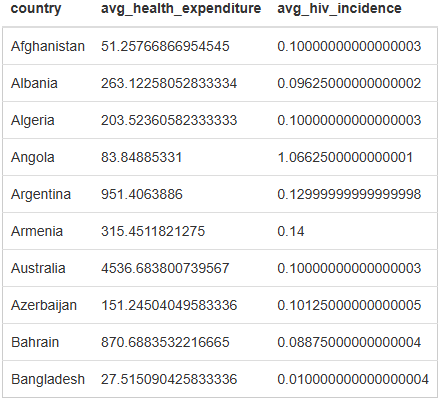

<p align="justify">
Output table above illustrates the first 10 rows from the overall table. The result is converted into a csv file named "health vs hiv.csv". A scatter plot of HIV incidence against health expenditure per capita based on the csv file is presented below:
</p>

Saving health vs hiv.csv to health vs hiv.csv
Correlation between Log(Health Expenditure per Capita) and HIV Incidence: -0.16


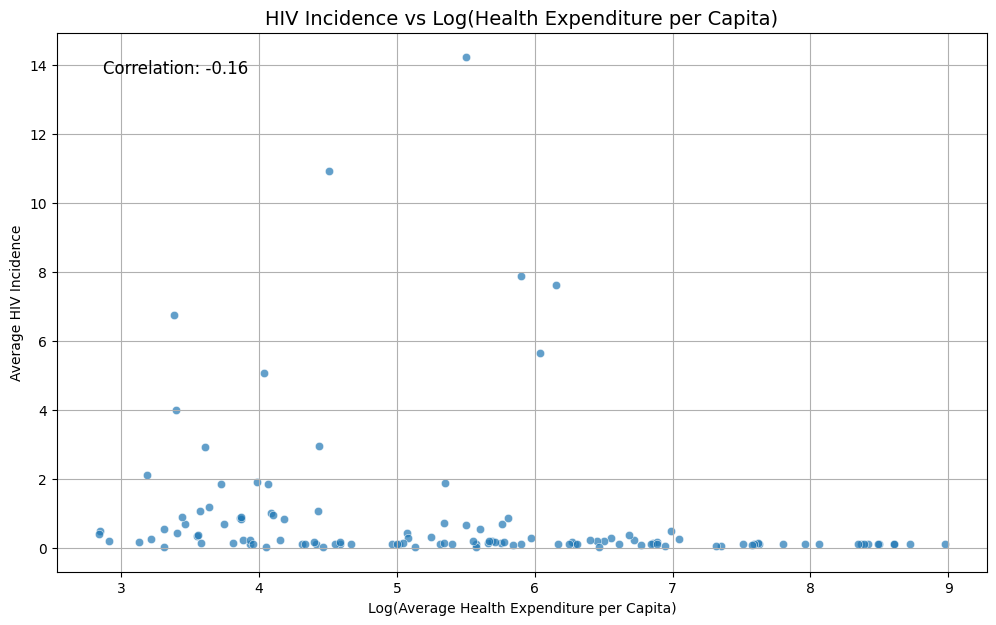

In [21]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("health vs hiv.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_health_expenditure"] = pd.to_numeric(
    result["avg_health_expenditure"],
    errors="coerce"
)

result["avg_hiv_incidence"] = pd.to_numeric(
    result["avg_hiv_incidence"],
    errors="coerce"
)

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(
    subset=["avg_health_expenditure", "avg_hiv_incidence"]
)

# ---------------------------------
# Log transformation (health expenditure)
# ---------------------------------
result["log_avg_health_expenditure"] = np.log(
    result["avg_health_expenditure"]
)

# Remove invalid log values
result = result.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ---------------------------------
# Correlation (log scale)
# ---------------------------------
correlation = result["log_avg_health_expenditure"].corr(
    result["avg_hiv_incidence"]
)

print(
    f"Correlation between Log(Health Expenditure per Capita) and HIV Incidence: {correlation:.2f}"
)

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="log_avg_health_expenditure",
    y="avg_hiv_incidence",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title(
    "HIV Incidence vs Log(Health Expenditure per Capita)",
    fontsize=14
)

plt.xlabel(
    "Log(Average Health Expenditure per Capita)"
)

plt.ylabel(
    "Average HIV Incidence"
)

plt.grid(True)

plt.show()

<p align="justify">
Log scaling is applied to health expenditure per capita due to its large spread. From the plot above, no clear trend or relationship is observed. Most of the data points are predominantly scattered at the bottom part of the plot, with only a few countries showing a significant number of HIV incidences. The correlation coefficient is -0.16, which suggests that health expenditure reacts inversely with HIV incidence. This is expected, as higher spending on medical services and HIV awareness campaigns can help reduce the number of HIV cases. However, the correlation is very low, which indicates a very weak negative relationship between health expenditure per capita and HIV incidence.
</p>
<p align="justify">
The weak relationship between health expenditure per capita and HIV incidence indicates that health expenditure alone is not sufficient to explain variations in HIV outcomes across countries. Although higher expenditure may improve accessibility to treatment and prevention programmes, HIV transmission is also strongly influenced by behavioural and social factors. These include levels of public awareness, education about safe practices, cultural attitudes and the effectiveness of national HIV prevention policies. In some countries, even with relatively high health expenditure, HIV incidence may remain high if prevention strategies are not effectively implemented or if awareness levels are low  (Witdiawati Witdiawati et al.,2025).
</p>
<p align="justify">
In addition, the weak correlation observed may be due to structural and demographic factors. The spread of HIV can be influenced by several other factors, namely population density, migration patterns, inequality and access to healthcare services within countries and this is independently of overall health spending levels. Furthermore, differences in reporting systems can also influence recorded HIV incidence. This will result in cross-country comparisons less precise. Therefore, even though health expenditure per capita is expected to play a role in reducing HIV incidence from improvisation of healthcare services and prevention efforts, the overall relationship is weak because HIV outcomes are shaped by a complex interaction of medical, social and economic factors (unaids.org).
</p>
<p align="justify">
OLS regression will be performed in order to identify the significance of the predictor; health expenditure per capita towards the HIV incidence. The hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is average health expenditure per capita.
</p>

####**Reference:**
Witdiawati Witdiawati et al. (2025). Contextual and culturally adapted interventions to improve HIV outcomes: a scoping review

(unaids.org) A framework for understanding and addressing HIV-related inequalities  from https://www.unaids.org/sites/default/files/media_asset/framework-understanding-addressing-hiv-related-inequalities_en.pdf

In [22]:
import statsmodels.api as sm

# Define the independent variable (X) as the log average of health expenditure per capita
X_health_hiv = result['log_avg_health_expenditure']
# Define the dependent variable (y) as the average HIV incidence
y_health_hiv = result['avg_hiv_incidence']

# Add a constant for the intercept
X_health_hiv_with_const = sm.add_constant(X_health_hiv)

# Fit the OLS regression model
model_health_hiv = sm.OLS(y_health_hiv, X_health_hiv_with_const, missing='drop').fit()

# Print the summary
print(model_health_hiv.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_hiv_incidence   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     3.339
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0701
Time:                        02:13:17   Log-Likelihood:                -261.67
No. Observations:                 123   AIC:                             527.3
Df Residuals:                     121   BIC:                             533.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

<p align="justify">
A very low R-squared value (0.027) based on the OLS regression results shown in the table above. Only 2.7% of the variation in HIV incidence is explained by health spending. This show that a very large share of the variation (around 97.3%) remains unexplained. This suggests that health expenditure alone is not a strong predictor of HIV incidence across countries. Instead, HIV outcomes are likely influenced by a wide range of other factors that are not captured in this model that may include medical, social and economic factors that mentioned previously.
</p>
<p align="justify">
The p-value for 'log_avg_health_expenditure' is 0.07. Since 0.07 is greater than the conventional significance level of 0.05, it failed to reject the null hypothesis. Therefore, there is no enough evidence to conclude that health expenditure has a significant effect on HIV incidence at the 5% significance level. Although the result suggests a weak relationship, it is not strong enough to be considered statistically significant under standard testing criteria. This may imply that any observed association could be due to random variation in the data rather than a true underlying effect.  
</p>

## **Health Expenditure per Capita and Density of Doctors Relationship**

<p align="justify">
Government spending on healthcare may include invesment towards expanding healthcare professionals such as nurses and doctors. Therefore, the relationship between health expenditure per capita and density of doctors is analysed to discover any potential relationship and the strength and significance of the relationship. Based on the cleaned datasets; "Health_Expenditure_per_Capita_Cleaned.csv" and "Density_of_Doctors_Cleaned.csv", the average of each variable is queried through HQL below:
</p>

```sql
SELECT h.country AS country,
       AVG(h.health_expenditure_per_capita) AS avg_health_expenditure,
       AVG(d.doctors_per_10k) AS avg_doctors_per_10k
FROM health_expenditure_per_capita_cleaned h
JOIN density_of_doctors_cleaned d
ON h.country = d.country
AND h.year = d.year
GROUP BY h.country;
```

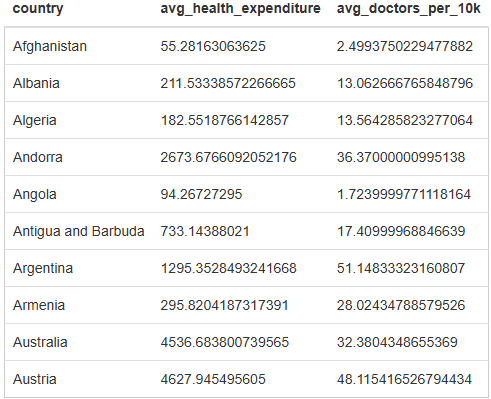

<p align="justify">
Above table only showed the first 10 rows of the overall output. The outut is converted into csv file "health vs doctors.csv" and a scatter plot of average density of doctors against health expenditure per capita is presented below:
</p>

Saving health vs doctors.csv to health vs doctors.csv
Correlation between Log(Health Expenditure per Capita) and Doctors per 10k Population: 0.77


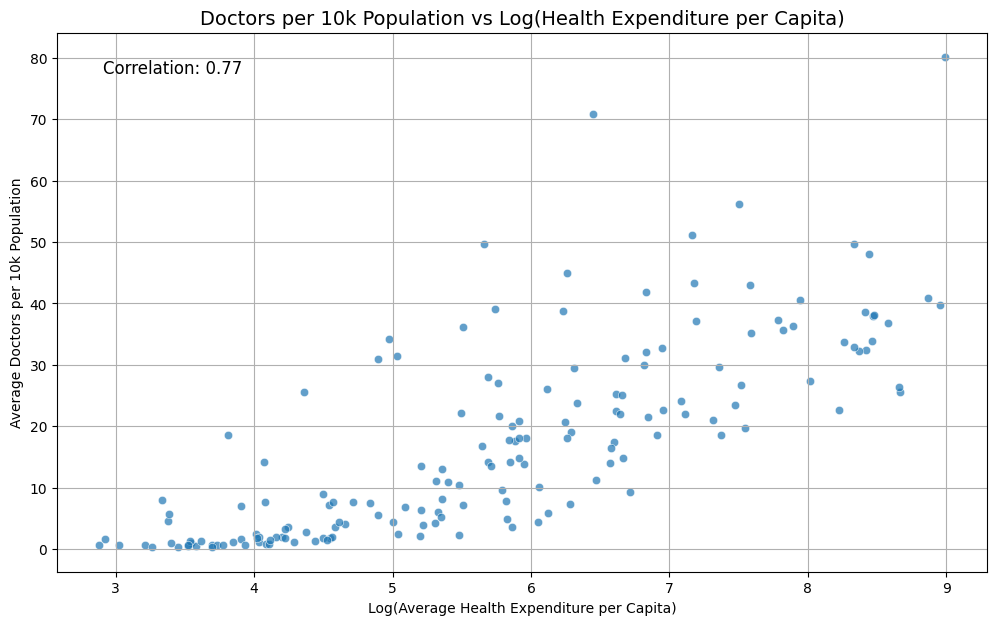

In [23]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("health vs doctors.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_health_expenditure"] = pd.to_numeric(
    result["avg_health_expenditure"],
    errors="coerce"
)

result["avg_doctors_per_10k"] = pd.to_numeric(
    result["avg_doctors_per_10k"],
    errors="coerce"
)

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(
    subset=["avg_health_expenditure", "avg_doctors_per_10k"]
)

# ---------------------------------
# Log transformation (health expenditure)
# ---------------------------------
result["log_avg_health_expenditure"] = np.log(
    result["avg_health_expenditure"]
)

# Remove invalid log values
result = result.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ---------------------------------
# Correlation (log scale)
# ---------------------------------
correlation = result["log_avg_health_expenditure"].corr(
    result["avg_doctors_per_10k"]
)

print(
    f"Correlation between Log(Health Expenditure per Capita) and Doctors per 10k Population: {correlation:.2f}"
)

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="log_avg_health_expenditure",
    y="avg_doctors_per_10k",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title(
    "Doctors per 10k Population vs Log(Health Expenditure per Capita)",
    fontsize=14
)

plt.xlabel(
    "Log(Average Health Expenditure per Capita)"
)

plt.ylabel(
    "Average Doctors per 10k Population"
)

plt.grid(True)

plt.show()

<p align="justify">
From the plot above, there is a positive relationship between health expenditure and density of doctors. Doctors' density increases as health expenditure increases. This is support with the correlation coefficient of 0.77 which indicate it has a strong positive correlation, meaning that countries with higher health expenditure per capita generally tend to have more doctors per 10,000 people. The points in the plot show an upward trend from the lower-left to the upper-right. Countries with low health expenditure (around log values of 3–5) tend to have very few doctors, often close to zero. In contrast, countries with higher health expenditure (above log value 7) tend to have a much higher number of doctors per population, ranging around 40–80 doctors per 10,000 people. This suggests that increased healthcare spending is associated with better healthcare workforce capacity.
</p>
<p align="justify">
The positive relationship is expected because higher healthcare expenditure per capita usually reflects a country's stronger investment in its overall health system, not just isolated components like medicines or hospital facilities. When more allocation towards healthcare funding is conducted by the govenrment, that spending tends to be distributed across multiple areas that collectively improve health outcomes. For instance, increased expenditure often leads to better equipped hospitals, improved access to essential medicines and more advanced medical technologies. At the same time, a significant portion of healthcare spending goes toward expanding and maintaining the healthcare workforce which include hiring more doctors, nurses and specialists. A higher density of medical professionals means patients can receive faster diagnoses, more timely treatment and better ongoing care, which contributes directly to lower mortality rates and improved life expectancy (Anca, 2025).
</p>
<p align="justify">
From this relationship analysis, there is clear strong positive relationship based on the plot. In order to statistically proof that there is enough evidence to conclude that health expenditure per capita affect density of doctors positively, the p-value for the predictor (health expenditure per capita) is calculated using OLS regression. For this relationship, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is average health expenditure per capita.
</p>

####**Reference:**
Anca Antoaneta Vărzaru (2025). Assessing the Relationships of Expenditure and Health Outcomes in Healthcare Systems: A System Design Approach

In [24]:
import statsmodels.api as sm

# Define the independent variable (X) as the log average of health expenditure per capita
X_health_doctors = result['log_avg_health_expenditure']
# Define the dependent variable (y) as the average number of doctors per 10,000 population
y_health_doctors = result['avg_doctors_per_10k']

# Add a constant for the intercept
X_health_doctors_with_const = sm.add_constant(X_health_doctors)

# Fit the OLS regression model
model_health_doctors = sm.OLS(y_health_doctors, X_health_doctors_with_const, missing='drop').fit()

# Print the summary
print(model_health_doctors.summary())

                             OLS Regression Results                            
Dep. Variable:     avg_doctors_per_10k   R-squared:                       0.597
Model:                             OLS   Adj. R-squared:                  0.594
Method:                  Least Squares   F-statistic:                     242.8
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):           3.56e-34
Time:                         02:18:32   Log-Likelihood:                -616.82
No. Observations:                  166   AIC:                             1238.
Df Residuals:                      164   BIC:                             1244.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

<p align="justify">
The regression results above indicate that healthcare expenditure is a statistically significant predictor of the number of doctors per 10,000 population, as evidenced by the p-value (0.000) of 'log_avg_health_expenditure' being less than 0.05. This suggest that there is strong evidence to reject the null hypothesis at 5% significance level. Hence, there is a meaningful and reliable relationship between the level of healthcare spending and the availability of medical professionals across countries.
</p>
<p align="justify">
Additionally, the R-squared value of 0.597 shows that approximately 59.7% of the variation in doctor density across countries can be explained by healthcare expenditure per capita. The variation is not significantly explain by the predictor, as around 40% of the variation remains unexplained which may imply that other structural and socioeconomic factors such as population size, government policy, medical education capacity and overall economic development may also play an important role in determining doctor availability.
</p>
<p align="justify">
Overall, the results suggest a clear and positive association between healthcare investment and healthcare workforce capacity. Countries that invest more heavily in healthcare are likely to not only improve infrastructure and service delivery but also strengthen their human resource capacity by training, attracting and retaining more doctors. Nevertheless, the moderate level of unexplained variation implies that healthcare expenditure alone is not sufficient to fully account for differences in doctor density.
</p>

## **GDP per Capita and CO2 Emissions Relationship**

<p align="justify">
To understand the environmental impact as a country develops, it is crucial to analyse the relationship between GDP per capita and CO2 emissions. Typically, countries with higher GDP per capita tend to have greater industrial activity, higher energy consumption and more developed transportation systems. All of this will most likely contribute to increased CO2 emissions. Before, the relationship is analysed, a comparison of CO2 emissions between highest and lowest GDP per capita nations is counducted to identify the trend between these two sets of nations
</p>
<p align="justify">
Below tables display top 10 and bottom 10 countries for GDP per capita value as of 2024.
</p>


```sql
SELECT t.country AS country,
       t.gdp_per_capita AS gdp_per_capita,
       t.year AS year
FROM gdp_per_capita_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM gdp_per_capita_cleaned
) y
ON t.year = y.latest_year
ORDER BY gdp_per_capita DESC
LIMIT 10;
```

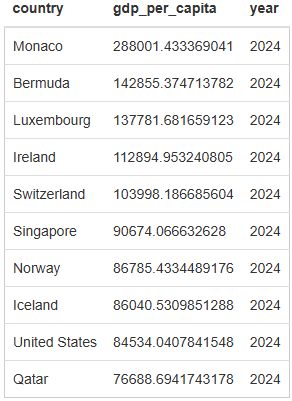

```sql
SELECT t.country AS country,
       t.gdp_per_capita AS gdp_per_capita,
       t.year AS year
FROM gdp_per_capita_cleaned t
JOIN (
    SELECT MAX(year) AS latest_year
    FROM gdp_per_capita_cleaned
) y
ON t.year = y.latest_year
ORDER BY gdp_per_capita ASC
LIMIT 10;
```

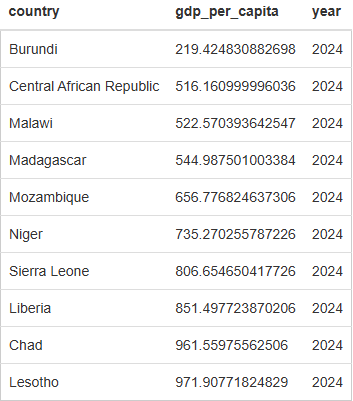

<p align="justify">
From the list of countries from the above tables, few countries are selected from the two sets of groups and CO2 emissions' trend accross years are visualised to get insights. Firstly, CO2 emission's trend for all country over the years are first organised in order in a table. This can be applied by executing the HQL query below from the cleaned "CO2_Emissions_Cleaned.csv" file.
</p>

```sql
SELECT country,
       year,
       co2_emissions
FROM co2_emissions_cleaned
GROUP BY country, year, co2_emissions
ORDER BY year ASC;
```

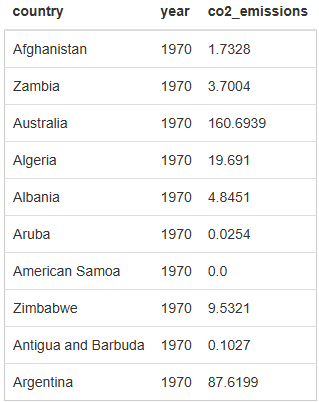

Table above displays the first 10 rows output from the query's execution previously. The overall output is converted into a csv file named "co2 emissions trend by country.csv" and CO2 emissions' trend of selected countries are displayed below:

Saving co2 emissions trend by country.csv to co2 emissions trend by country.csv


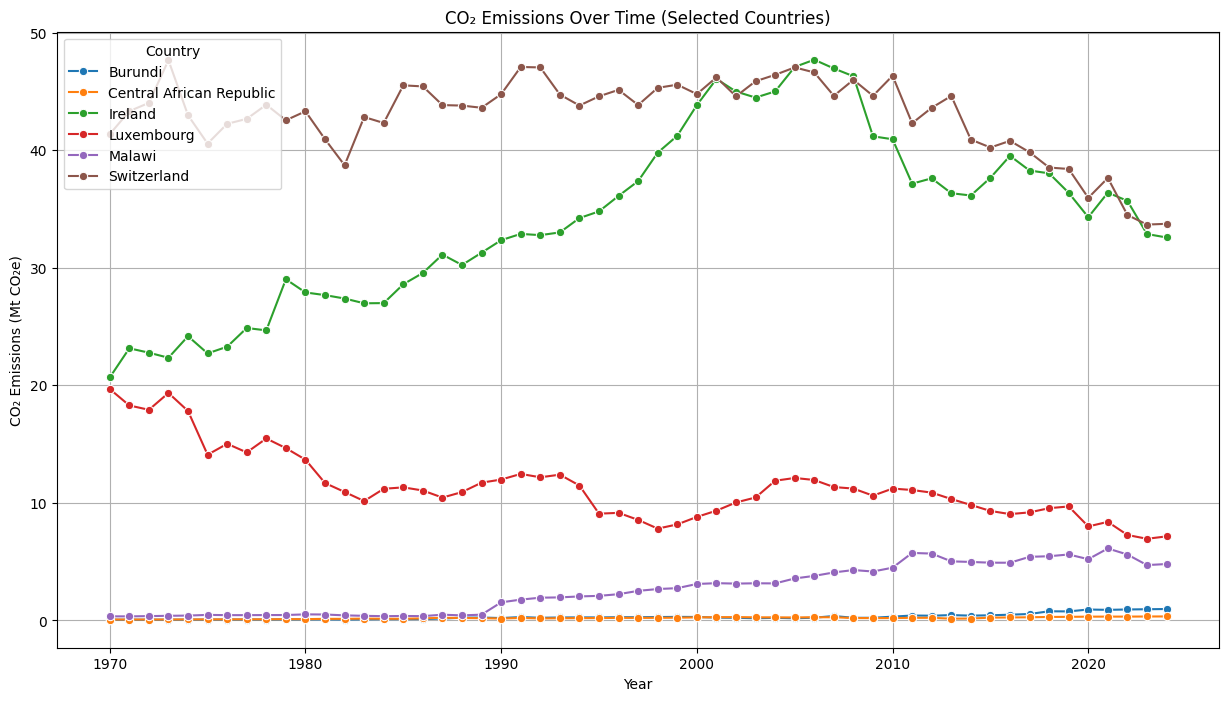

In [25]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

# ---------------------------------
# Load CO2 trend CSV
# ---------------------------------
df_co2 = pd.read_csv("co2 emissions trend by country.csv")

# ---------------------------------
# Convert data types
# ---------------------------------
df_co2["year"] = df_co2["year"].astype(int)
df_co2["co2_emissions"] = pd.to_numeric(
    df_co2["co2_emissions"],
    errors="coerce"
)

# ---------------------------------
# Select sample countries
# ---------------------------------
countries = [
    "Ireland",
    "Switzerland",
    "Luxembourg",
    "Central African Republic",
    "Malawi",
    "Burundi"
]

df_sample = df_co2[
    df_co2["country"].isin(countries)
]

# ---------------------------------
# Sort values for time series
# ---------------------------------
df_sample = df_sample.sort_values(
    ["country", "year"]
)

# ---------------------------------
# Plot time series
# ---------------------------------
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=df_sample,
    x="year",
    y="co2_emissions",
    hue="country",
    marker="o"
)

# ---------------------------------
# Styling
# ---------------------------------
plt.title("CO₂ Emissions Over Time (Selected Countries)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt CO₂e)")
plt.grid(True)

plt.legend(
    title="Country",
    loc="upper left"
)

plt.show()

<p align="justify">
From the trend plot above, Switzerland has the highest total CO2 emissions with generally over 40 Mt CO2e accross past decades before dropping 2010 onwards to just over 30 Mt CO2e in 2024. Ireland's CO2 emissions started of at 20 Mt CO2e in 1970 before increase gradually over the decades to over 40 Mt CO2e in 2005, before decreased to just over 30 Mt CO2e in 2024 at quite similar rate as Switzerland's. Luxembourg has the third highest CO2 emissions from 1970 to 2024 ranging from 10 to 20 Mt CO2e. Malawi, Burundi and Central African Republic have very low CO2 emission with two of the countries emitted near 0 Mt CO2e of CO2 except Malawi (5 Mt CO2e).
</p>
<p align="justify">
Ireland's CO2 emissions reached a peak around 2005, largely as a consequence of the strong economic growth during the “Celtic Tiger” period. This rapid expansion increased overall energy demand across both households and industries. A key contributor was the electricity sector, which at the time still relied heavily on carbon-intensive fuels such as coal, peat and oil. In addition, rising incomes led to higher private vehicle ownership which significantly increase transport-related emissions. The construction boom during this period also intensified energy use through large-scale infrastructure development, cement production and material transportation.
However after this peak, Ireland's emissions began to decline due to improvements in energy efficiency, the gradual transition toward natural gas and renewable energy (particularly wind power), and the effects of EU climate policies and economic slowdown following the 2008 financial crisis (Tianning Zhao et al. 2026).
</p>
<p align="justify">
All the countries with low GDP per capita in the above plot tend to emit less CO2 compared to countries with higher GDP per capita. This is because lower income countries typically have less industrial activity, lower levels of energy consumption and reduced access to carbon-intensive technologies. Their economies are often more reliant on agriculture and informal sectors rather than manufacturing and heavy industry, which are major sources of greenhouse gas emissions.
</p>
<p align="justify">
In contrast, wealthy countries have more developed industrial sectors, higher electricity demand, greater transportation usage and higher consumption levels overall. All these activities require more energy, which is still largely derived from fossil fuels which lead to higher CO2 emissions. Additionally, wealthier populations tend to consume more goods and services, many of which are produced through energy intensive global supply chains.
</p>

####**Reference:**
Tianning Zhao et al. (2026). Ireland’s carbon emission trends and degrowth opportunities: Based on modified Tapio - LMDI model

<p align="justify">
Based on the selected countries CO2 emissions trend, it seemed that countries with higher GDP per capita emit CO2 compared to countries with lower GDP per capita. To justify this, an analysis regarding their relationship must be investigated to get a true overview of their relationship. As applied in previous relationships, the average for each variables by country need to be calculated first and this can be executed through the HQL query below:
</p>

```sql
SELECT g.country AS country,
       AVG(g.gdp_per_capita) AS avg_gdp,
       AVG(c.co2_emissions) AS avg_co2_emissions
FROM gdp_per_capita_cleaned g
JOIN co2_emissions_cleaned c
ON g.country = c.country
AND g.year = c.year
GROUP BY g.country;
```

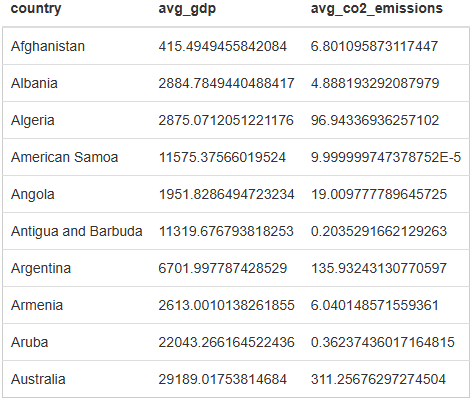

Table above illustrates the first 10 rows from the query's output. To get overall relationship, a scatter plot of average CO2 emissions against GDP per capita need to be plotted to uncover the relationship that may exist between these indicators. Therefore, the overall output from the query above will be converted into a csv file called "gdp vs co2.csv" and the scatter plot will be generated and this is shown below:

Saving gdp vs co2.csv to gdp vs co2.csv
Correlation between Log(GDP per Capita) and Log(CO2 Emissions): 0.20


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


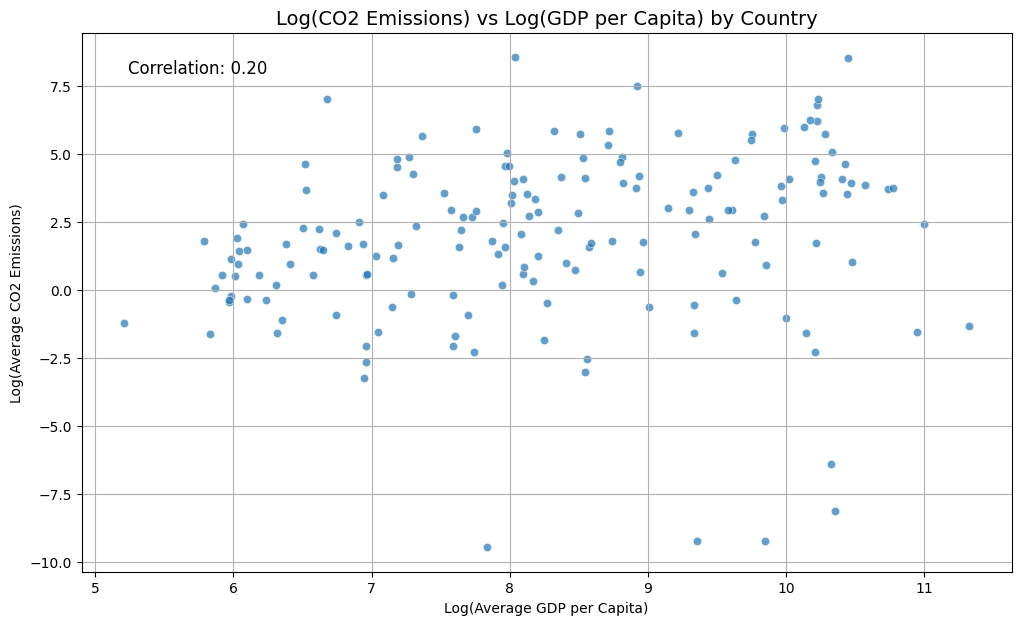

In [26]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

uploaded = files.upload()

# ---------------------------------
# Load pre-aggregated CSV
# ---------------------------------
result = pd.read_csv("gdp vs co2.csv")

# ---------------------------------
# Ensure numeric types
# ---------------------------------
result["avg_gdp"] = pd.to_numeric(
    result["avg_gdp"],
    errors="coerce"
)

result["avg_co2_emissions"] = pd.to_numeric(
    result["avg_co2_emissions"],
    errors="coerce"
)

# ---------------------------------
# Drop missing values
# ---------------------------------
result = result.dropna(
    subset=["avg_gdp", "avg_co2_emissions"]
)

# ---------------------------------
# Log transformation (both variables)
# ---------------------------------
result["log_avg_gdp"] = np.log(result["avg_gdp"])
result["log_avg_co2_emissions"] = np.log(result["avg_co2_emissions"])

# Remove invalid log values
result = result.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ---------------------------------
# Correlation (log scale)
# ---------------------------------
correlation = result["log_avg_gdp"].corr(
    result["log_avg_co2_emissions"]
)

print(
    f"Correlation between Log(GDP per Capita) and Log(CO2 Emissions): {correlation:.2f}"
)

# ---------------------------------
# Scatter plot
# ---------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=result,
    x="log_avg_gdp",
    y="log_avg_co2_emissions",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05, 0.95,
    f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# ---------------------------------
# Labels and title
# ---------------------------------
plt.title(
    "Log(CO2 Emissions) vs Log(GDP per Capita) by Country",
    fontsize=14
)

plt.xlabel("Log(Average GDP per Capita)")
plt.ylabel("Log(Average CO2 Emissions)")
plt.grid(True)

plt.show()

<p align="justify">
For the plot above, few tweaks have been made to make the plot look more presentable. Both CO2 emissions and GDP per capita are log scaled since they ranges from a few hundred to tens of thousands. Using log scale spreads points out nicely. From the plot above, the data points are not scattered nicely and the trend cannot be visualised clearly. Although it seemed like there is small upward trend between GDP per capita and CO2 emissions, the relationship is not visible enough. This is explained by the correlation coefficient of 0.20. There is positive correlation between GDP per capita and CO2 emissions but the relationship is very weak and it is close to value "0" which indicate that the positive correlation is very minimal.
</p>
<p align="justify">
There are few reasons on why the relationship between GDP per capita and CO2 emissions is weak. First, GDP per capita only measure the average economic output with no direct association and impact towards CO2 emission. CO2 emission levels is depend on energy sources, industrial activities and the usage of technology that the countries adopt. For example, countries that depend more on fossil fuels may produce higher CO2 emissions compared to countries that use renewable energy.
</p>
<p align="justify">
Besides, government policies, economic structure and population characteristics and behaviour also has influence on the levels of CO2 emissions. Wealthier countries tend to reduce emissions through cleaner technologies, energy efficiency and environmental regulations as part of moving towards greener economy. Meanwhile, developing countries may experience higher emissions due to industrialization and urban growth. Therefore, GDP per capita alone cannot fully explain CO2 emission differences, resulting in a very weak relationship between the two indicators.
</p>
<p align="justify">
OLS regression is performed to investigate the the variation of CO2 emission based on GDP per capita which act as predictor in this case. P-value will also determine the significance of GDP per capita towards CO2 emissions. For this relationship, the hypotheses are

$$
H_0: \beta_1 = 0
$$

$$
H_1: \beta_1 \neq 0
$$

where $\beta_1 \$ is log of average GDP per capita.
</p>

In [27]:
import statsmodels.api as sm

# Define the independent variable (X) as the log average of GDP per capita
X_gdp_co2 = result['log_avg_gdp']
# Define the dependent variable (y) as the log average of CO2 emissions
y_gdp_co2 = result['log_avg_co2_emissions']

# Add a constant for the intercept
X_gdp_co2_with_const = sm.add_constant(X_gdp_co2)

# Fit the OLS regression model
model_gdp_co2 = sm.OLS(y_gdp_co2, X_gdp_co2_with_const, missing='drop').fit()

# Print the summary
print(model_gdp_co2.summary())

                              OLS Regression Results                             
Dep. Variable:     log_avg_co2_emissions   R-squared:                       0.039
Model:                               OLS   Adj. R-squared:                  0.034
Method:                    Least Squares   F-statistic:                     6.981
Date:                   Sun, 07 Jun 2026   Prob (F-statistic):            0.00901
Time:                           02:30:09   Log-Likelihood:                -433.01
No. Observations:                    172   AIC:                             870.0
Df Residuals:                        170   BIC:                             876.3
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.49

<p align="justify">
From the regression results above, R-squared value is 0.039 which indicate that only 3.9% of log average of CO2 emissions is explained by log average of GDP per capita. The value is very low which mean that about 96.1% of log average of CO2 emissions remains unexplained. In terms of p-value, its p-value is 0.009 which is less than the conventional significance level of 0.05. It means that the null hypothesis is rejected and hence indicate there is statistically significant evidence to suggest that log average of GDP per capita influences log average of CO2 emissions.  
</p>
<p align="justify">
Overall, GDP per capita is a statistically significant predictor for CO2 emissions. However, they have a very weak positive relationship based on low correlation value of 0.20. An increase in GDP per capita will result in the increase of CO2 emissions but on very low impact. The variability of CO2 emissions also less explained by GDP per capita based on the R-squared value. This indicate that, there are other important factors that can explain CO2 emissions such as government policies and economic structures to name a few as mentioned previously.
</p>

## **Overall Overview of Relationships between Indicators**

<p align="justify">
Based on the overall relationship analysis from previous sections, several take aways can be extracted from the observed relationships. First of all, GDP per capita shows a very strong positive correlation with health expenditure per capita and it is statistically a significant predictor. An increase in GDP per capita will result in the increase of health expenditure per capita. Furthermore, the relationships between health expenditure per capita and other health indicators such as life expectancy, under-five mortality rate, HIV incidence and density of doctors, were analysed. Health expenditure per capita was used as the main indicator to examine whether greater healthcare investment contributes to improved health outcomes. The analysis helps to identify whether higher spending on healthcare is associated with better healthcare accessibility, improved medical services and overall population health.
</p>

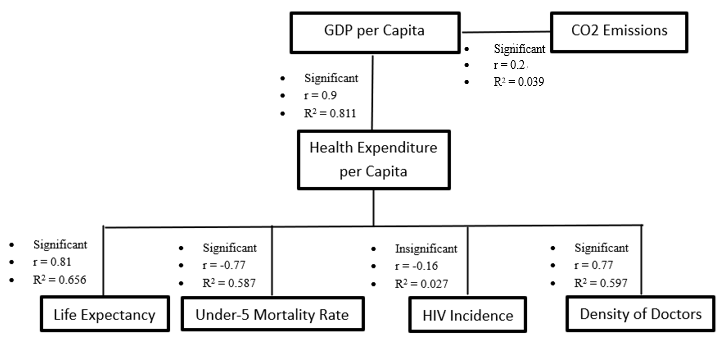

<p align="justify">
Diagram above shows overall relationships analysed from previous sections. The results show that health expenditure per capita is an important but not exclusive determinant of health outcomes and healthcare system capacity. Across most indicators, log-scaled health expenditure is used to address large cross-country differences and the correlations generally reveal meaningful relationships between spending and outcomes. However, the strength and significance of these relationships vary depending on the specific health indicator, suggesting that healthcare spending interacts with broader socioeconomic and structural factors rather than acting in isolation.
</p>
<p align="justify">
For life expectancy and under-five mortality rate, the results show strong and consistent relationships with health expenditure per capita. Life expectancy has positive  relationship with health spending, with a strong correlation (0.81) and have a moderate explanatory power (R² = 0.656). This indicates that higher investment on healthcare lead to longer lifespans which is likely through improved access to services, medical technology and disease prevention. Similarly, under-five mortality rate shows a strong negative relationship (correlation = -0.77, R² = 0.587). This means higher health expenditure is associated with fewer child deaths. Both relationships are statistically significant, reinforcing that healthcare expenditure plays a key role in improving general and child health outcomes even though other factors such as income, education and sanitation also contribute meaningfully to the variation observed.
</p>
<p align="justify">
In contrast, health expenditure per capita and HIV incidence has a weak relationship and the predictor (health expenditure per capita) is statistically insignificant, with a very low R² (0.027) and a weak negative correlation (-0.16). This suggest spending alone does not meaningfully explain differences in HIV rates across countries. This reflects the strong influence of non-financial factors such as behaviour, awareness, policy effectiveness and reporting differences. On the other hand, health expenditure and doctor density has a strong and positive (correlation = 0.77, R² = 0.597) relationship. This indicates that higher spending on healthcare is associated with a larger healthcare workforce. Overall, the findings indicate that while healthcare expenditure is strongly linked to structural capacity such as doctor supply and key outcomes like life expectancy and child mortality, its effect is limited for complex, behaviour-driven diseases like HIV which highlight the importance of broader social, economic and policy determinants.
</p>
<p align="justify">
As for GDP per capita and CO2 emissions relationship, they have a very weak positive correlation (0.2). This suggests that although higher GDP per capita is associated with slightly higher CO2 emissions, the relationship is minimal and not strong enough to clearly explain emissions patterns. The regression results also shows a very low R² value (0.039), meaning GDP per capita only explained a very small part of CO2 emissions. The majority remains driven by other factors. Despite this weak explanatory power, the relationship is still statistically significant. This indicates that GDP per capita does have a measurable but limited influence on CO2 emissions. Overall, while economic output has some association with emissions, CO2 levels are far more strongly shaped by other factors such as energy sources, industrial structure, technology use and environmental policies.
</p>

## **Life Expectancy Forecast**

<p align="justify">
As one of the most important health indicator and widely use accross the globe, life expectancy is vital to determine health outcome. Global life expectancy trend has been observed previously and there was a slight drop 2019 onward and this is due to the pandemic Covid-19 during that time and it affects the global lifespan until now without any sign of recovering. This is a worrying sign and therefore, forecasting of life expectancy is conducted to forecast future life expectancy and take necessary actions where required based on the forecast outcome. The prophet model is a useful time series model for forecasting as it captures the trend and seasonality components. However, since life expectancy is unlikely to have seasonality component, only trend component is captured and based on. The forecast of global life expectancy over the next 10 years is shown in below plot:
</p>

In [ ]:
# Install Prophet library if not already installed
!pip install prophet

Based on the csv file "global life expectancy trend.csv",

Saving global life expectancy trend.csv to global life expectancy trend (1).csv


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 16.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


           ds       yhat  yhat_lower  yhat_upper
27 2026-12-31  71.553759   71.093474   71.984100
28 2027-12-31  71.505571   70.964764   71.987072
29 2028-12-31  71.457251   70.833094   72.060588
30 2029-12-31  71.409063   70.661881   72.120375
31 2030-12-31  71.360875   70.465214   72.167253


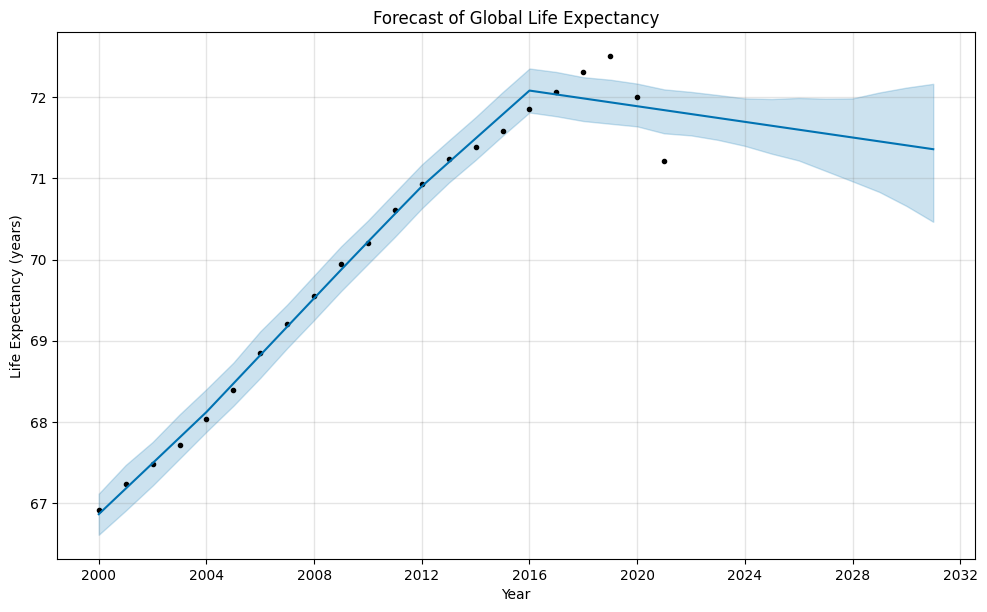

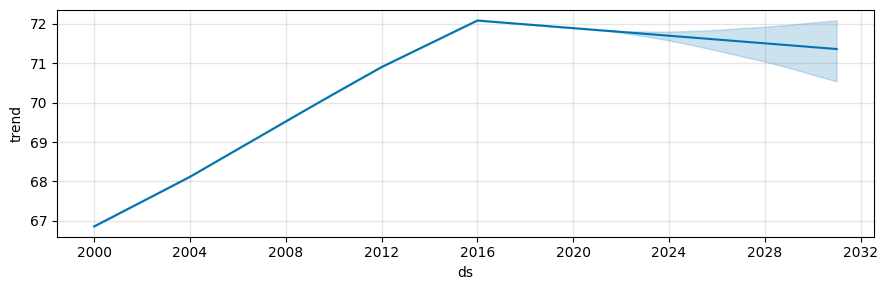

In [28]:
import pandas as pd
from google.colab import files
from prophet import Prophet
import matplotlib.pyplot as plt

uploaded = files.upload()

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("global life expectancy trend.csv")

# ----------------------------
# 2. Convert data types
# ----------------------------
df["year"] = df["year"].astype(int)
df["global_avg_life_expectancy"] = pd.to_numeric(
    df["global_avg_life_expectancy"],
    errors="coerce"
)

# ----------------------------
# 3. Drop missing values
# ----------------------------
df = df.dropna(subset=["global_avg_life_expectancy"])

# ----------------------------
# 4. Prepare data for Prophet
# ----------------------------
df_prophet = df.rename(columns={
    "year": "ds",
    "global_avg_life_expectancy": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

# ----------------------------
# 5. Fit Prophet model
# ----------------------------
model = Prophet(yearly_seasonality=False)
model.fit(df_prophet)

# ----------------------------
# 6. Future forecasting (10 years)
# ----------------------------
future = model.make_future_dataframe(periods=10, freq="Y")
forecast = model.predict(future)

# ----------------------------
# 7. Show forecast output
# ----------------------------
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

# ----------------------------
# 8. Forecast plot ONLY
# ----------------------------
fig1 = model.plot(forecast)
plt.title("Forecast of Global Life Expectancy")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.show()

# ----------------------------
# 9. Components ONLY
# ----------------------------
fig2 = model.plot_components(forecast)
plt.show()

<p align="justify">
Based on the plot above, the forecasted global life expectancy shows a slight  declining trend over the next decade, reaching just above 71 years. The 95% prediction interval (blue shaded area) suggests that the expected values are likely to fall within a narrow range of slightly below 71 to around 72 years, indicating relatively low uncertainty in the short-term forecast. The trend component of the model also reflects this gradual downward movement in life expectancy over time.
</p>
<p align="justify">
Overall, this suggests a modest but consistent decline in global life expectancy based on the model projections. Although the change might seem small, it is still concerning because life expectancy is generally expected to improve over time due to advances in healthcare, technology and living standards. This is not the case with the forecast plot above. Hence, this downward trend should be interpreted with caution, as it may also reflect limitations based on the data aggregation or recent short term disruption (COVID-19 pandemic) rather than a true long-term global deterioration.
</p>
<p align="justify">
In order to address this projected decline, several policy and public health interventions can be considered. Healthcare systems need to be strengthen especially in low and middle income countries. Easy access to essential services, early disease detection and treatment outcomes should be the plan for these countries. Since, health expenditure is a significant preditor for life expectancy based on previous analysis, increased investment by governments in preventive healthcare such as vaccination programs, maternal care and chronic disease prevention can also significantly help improve the population's health outcomes. Finally, preparation of public health is also crucial based on recent COVID-19 pandemic have demonstrated it massive impact on mortality and life expectancy trends.
</p>

### **RECOMMENDATIONS**

<p align="justify">
Based on the analysis of population, economic, healthcare and environmental indicators, the primary focus of all countries are towards strengthening healthcare investment while ensuring that resources are allocated effectively. The positive relationship between health expenditure per capita and life expectancy suggests that increased healthcare spending can contribute to improved health outcomes. However, healthcare investment should not only focus on increasing expenditure but also prioritize preventive healthcare, vaccination programs, disease prevention, access to medicine and improvement of healthcare facilities. Efficient allocation of healthcare resources is important to ensure that higher spending translates into meaningful improvements in population health.
</p>

<p align="justify">
Furthermore, investment in healthcare workforce development should be emphasized to improve the accessibility and quality of healthcare services. The relationship between health expenditure per capita and density of doctors indicates that increased healthcare funding can support the expansion of medical professionals and healthcare capacity. Therefore, governments should invest in medical education, training programs and strategies to reduce shortages of healthcare workers. A stronger healthcare workforce can improve early disease detection, treatment availability and overall healthcare system performance.
</p>

<p align="justify">
Countries should also work towards reducing inequalities in health outcomes by ensuring that economic growth contributes to better living conditions and healthcare access. Since GDP per capita is closely associated with various health indicators, lower-income countries may require stronger healthcare infrastructure development, targeted public health programs and international cooperation to improve health outcomes. Economic development should not only focus on increasing national income but also ensure that the benefits of growth are distributed effectively across populations.
</p>

<p align="justify">
In addition, sustainable economic growth should be prioritized to balance development with environmental protection. The relationship between GDP per capita and CO2 emissions highlights that economic expansion can increase environmental pressure, particularly through higher energy consumption and industrial activities. Therefore, countries should adopt greener development strategies by investing in renewable energy, cleaner technologies, sustainable transportation and improved energy efficiency. Developed economies should take a leading role in reducing emissions, while developing countries should be supported in achieving economic growth through environmentally sustainable approaches.
</p>

<p align="justify">
Based on the overall relationships between the indicators, policymakers should adopt a data-driven approach when designing strategies and making decisions. Economic, healthcare, population and environmental factors are interconnected, meaning that improvements in one area may influence outcomes in another. Continuous monitoring and analysis of these indicators can help governments identify challenges, evaluate policy effectiveness and develop more targeted interventions.
</p>

<p align="justify">
Finally, the life expectancy forecast suggests that future healthcare demands may continue to increase, requiring countries to prepare their healthcare systems for long term challenges. Governments should strengthen healthcare planning by improving elderly care services, expanding preventive healthcare programs and preparing sufficient medical resources for future population needs. Future studies could also include additional socioeconomic factors such as education level, income inequality and access to basic services, while applying more advanced analytical methods such as multiple regression or machine learning models to provide deeper insights into the relationships between indicators.  
</p>

### **INTERACTIVE DATA QUERY SYSTEM**

<p align="justify">
For this section, a simple interactive data query system was developed to extract specific country-level attributes by providing the country and year as user inputs. The development process began by integrating all cleaned datasets used in this project through a HQL query, as shown below:
</p>

```sql
CREATE VIEW health_economic_environmental_summary AS
SELECT p.country,
       p.year,
       l.life_expectancy,
       h.health_expenditure_per_capita,
       m.under_5_mortality_rate,
       c.co2_emissions,
       i.hiv_incidence,
       d.doctors_per_10k,
       g.gdp_per_capita,
       p.total_population
FROM total_population_cleaned p
LEFT JOIN life_expectancy_cleaned l
    ON p.country = l.country AND p.year = l.year
LEFT JOIN health_expenditure_per_capita_cleaned h
    ON p.country = h.country AND p.year = h.year
LEFT JOIN under_5_mortality_rate_cleaned m
    ON p.country = m.country AND p.year = m.year
LEFT JOIN co2_emissions_cleaned c
    ON p.country = c.country AND p.year = c.year
LEFT JOIN hiv_infections_cleaned i
    ON p.country = i.country AND p.year = i.year
LEFT JOIN density_of_doctors_cleaned d
    ON p.country = d.country AND p.year = d.year
LEFT JOIN gdp_per_capita_cleaned g
    ON p.country = g.country AND p.year = g.year;
```

<p align="justify">
The query above creates a virtual table called "health_economic_environmental_summary". The table joined all the indicators' cleaned datasets with the pre set based dataset, which is "total_population_cleaned". "LEFT JOIN" is applied to ensure that all rows are included since some of the indicators have missing values for certain countries or years. All rows are needed for the table to make sure all the available data from each dataset are not left out and ignored. The "LEFT JOIN" will combine all subsequent datasets based on country and year. Once the virtual table is created, another HQL query is required to display the desired output, which is the overall overview of all indicators in a single dataset. The query is shown below:
</p>

```sql
SELECT
    country AS country,
    year AS year,
    life_expectancy AS life_expectancy,
    health_expenditure_per_capita AS health_expenditure_per_capita,
    co2_emissions AS co2_emissions,
    under_5_mortality_rate AS under_5_mortality_rate,
    hiv_incidence AS hiv_incidence,
    doctors_per_10k AS doctors_per_10k,
    gdp_per_capita AS gdp_per_capita,
    total_population AS total_population
FROM health_economic_environmental_summary
WHERE year >= 2000;
```

<p align="justify">
This query extracts the required attributes from the "health_economic_environmental_summary" virtual table, renamed the column name accordingly and only filter for year 2000 onwards. This filtering step was performed to reduce unnecessary historical records, improve query performance and maintain a manageable dataset size for subsequent interactive analysis. The processed output was exported as "health_economic_environmental_summary.csv" and later utilised in Python to enable interactive data retrieval based on user inputs.
</p>
<p align="justify">
Python code below loads the csv file and print out the available columns for the loaded dataset.
</p>

In [29]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

# Load CSV file
summary = pd.read_csv("health_economic_environmental_summary.csv")

# Display available columns
print(summary.columns)

Saving health_economic_environmental_summary.csv to health_economic_environmental_summary.csv
Index(['country', 'year', 'life_expectancy', 'health_expenditure_per_capita',
       'co2_emissions', 'under_5_mortality_rate', 'hiv_incidence',
       'doctors_per_10k', 'gdp_per_capita', 'total_population'],
      dtype='object')


<p align="justify">
The interactive query code is presented below. Users are required to input the desired country and year before selecting the specific indicators they wish to extract. The system will then retrieve and display the corresponding values based on the provided inputs.
</p>

In [30]:
import pandas as pd

# Load dataset
summary = pd.read_csv("health_economic_environmental_summary.csv")

# Clean column names
summary.columns = summary.columns.str.strip().str.lower().str.replace(" ", "_")

# Display available indicators
indicators = [
    col for col in summary.columns
    if col not in ["country", "year"]
]

print("Available indicators:")
for i in indicators:
    print("-", i)


# User input
country_input = input("\nEnter country: ")
year_input = int(input("Enter year: "))

indicator_input = input(
    "\nEnter indicator name: "
).lower().replace(" ", "_")


# Filter data
result = summary[
    (summary["country"].str.lower() == country_input.lower()) &
    (summary["year"] == year_input)
]


# Display result
if result.empty:
    print("\nNo data found for the given country and year.")
else:
    if indicator_input in indicators:
        value = result[indicator_input].values[0]

        print("\nResult:")
        print(f"Country: {country_input}")
        print(f"Year: {year_input}")
        print(f"{indicator_input}: {value}")

    else:
        print("\nInvalid indicator.")
        print("Please choose from:")
        for i in indicators:
            print("-", i)

Available indicators:
- life_expectancy
- health_expenditure_per_capita
- co2_emissions
- under_5_mortality_rate
- hiv_incidence
- doctors_per_10k
- gdp_per_capita
- total_population

Enter country: malaysia
Enter year: 2018

Enter indicator name: life_expectancy

Result:
Country: malaysia
Year: 2018
life_expectancy: 72.61026


<p align="justify">
This interactive data query system is expected to enable users to efficiently retrieve specific attributes based on the selected country and year inputs.
</p>

### **CONCLUSION**

<p align="justify">
There are a lot of things discussed in this project. Populations trend by country is observed and top 10 and bottom 10 countries were displayed and there were massive gap between the number of populations between biggest nations and smallest nations and it is mainly due to the the size of land area. Then, GDP per capita is analysed and comparison is made between countries with highest GDP per capita and lowest GDP per capita. Countries with highest GDP per capita are predominantly small nations but there are few exception such as the United States and Norway. Meanwhile, countries in Africa region dominate the list for nations with lowest GDP per capita and this is expected due to poor economy condition in that region.   
</p>
<p align="justify">
Next, life expectancy is analysed whereby the trend implied declining trend especially from 2019 onward. The huge factor behind this is the global pandemic, COVID-19 which started in 2019 and the life expectancy is yet to recover until now. Relationships between indicators are then observed to uncover any meaningful insight about their correlation with each other. The main economic indicator, GDP per capita is analysed with health expenditure per capita (health indicator) and the result showed positive strong correlation between the indicators.
</p>
<p align="justify">
Taking health expenditure per capita as the predictor for the other health indicators used in this research, namely life expectancy, under-five mortality rate, HIV incidence and density of doctors, more insights about the relationships were extracted. For instance, positive associations of health spending with life expectancy and density of doctors and negative associations with under-five mortality rate and HIV incidence. There was an indicator that appeared statistically insignificant and that is health expenditure towards HIV incidence. A variety of correlation strength, explanatory power of the indicators were also observed. The relationship analysis is not limited to only economic and health indicators, the environmental indicator; CO2 emissions was also analysed against the GDP per capita. Overall overview of all the relationships were also analysed and projection of global life expectancy forecast was also conducted and analysed.
</p>
<p align="justify">
Based on the analyses, recommendations were then proposed on how countries can implement appropriate strategies and take necessary actions to achieve optimal outcomes. In the final section, a simple interactive data query system is developed to enable users to efficiently extract relevant countries' attributes information. Overall, hopefully this project will be able to provide meaningful insights not limited to global health analytics only but also other sector such as economic and enviroment. Ideally, this project will also be a platform to discover more suitable and related indicators for future analysis or project.
</p>